# Load packages and libraries

In [1]:
.libPaths()
.libPaths(new = c("/home/manuel.tardaguila/conda_envs/multiome_QC_DEF/lib/R/library"))
.libPaths()
# sessionInfo()

Sys.setenv(RETICULATE_PYTHON="/home/manuel.tardaguila/conda_envs/multiome_QC_DEF/bin/python")
library(reticulate)
reticulate::use_python("/home/manuel.tardaguila/conda_envs/multiome_QC_DEF/bin/python")
reticulate::use_condaenv("/home/manuel.tardaguila/conda_envs/multiome_QC_DEF")
reticulate::py_module_available(module='leidenalg')
reticulate::import('leidenalg')
suppressMessages(library("optparse"))
suppressMessages(library(hdf5r))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(EnsDb.Hsapiens.v86))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(Matrix))
suppressMessages(library(data.table))
suppressMessages(library(ggpubr))
suppressMessages(library(ggplot2))
suppressMessages(library(scDblFinder))
suppressMessages(library("tidyr"))
suppressMessages(library("tibble"))
suppressMessages(library("biovizBase"))
suppressMessages(library("patchwork"))
suppressMessages(library(glmGamPoi))
suppressMessages(library(SeuratData))
suppressMessages(library(SeuratDisk))
library(svglite)
library(RColorBrewer)




[1] "/home/manuel.tardaguila/R/x86_64-conda-linux-gnu-library/4.3"    
[2] "/home/manuel.tardaguila/conda_envs/multiome_QC_DEF/lib/R/library"

[1] "/home/manuel.tardaguila/conda_envs/multiome_QC_DEF/lib/R/library"

[1] TRUE

Module(leidenalg)

Warning message:
“package ‘optparse’ was built under R version 4.3.3”
Warning message:
“package ‘Seurat’ was built under R version 4.3.2”
Warning message:
“package ‘Signac’ was built under R version 4.3.2”
Warning message:
“package ‘ensembldb’ was built under R version 4.3.2”
Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”
Warning message:
“package ‘GenomicRanges’ was built under R version 4.3.2”
Warning message:
“package ‘S4Vectors’ was built under R version 4.3.2”
Warning message:
“package ‘IRanges’ was built under R version 4.3.2”
Warning message:
“package ‘GenomeInfoDb’ was built under R version 4.3.2”
Warning message:
“package ‘GenomicFeatures’ was built under R version 4.3.2”
Warning message:
“package ‘AnnotationDbi’ was built under R version 4.3.2”
Warning message:
“package ‘Biobase’ was built under R version 4.3.2”
Warning message:
“package ‘AnnotationFilter’ was built under R version 4.3.2”
Warning message:
"package 'scDblFinder' was built under R ver

In [2]:
suppressMessages(library(svglite))
suppressMessages(library(RColorBrewer))
suppressMessages(library(forcats))
suppressMessages(library(cowplot))
suppressMessages(library(plyr))

In [3]:
#AvailableData()

# Read objects merged_unprocessed_db_filt_clustered_QCed

In [5]:
setwd("/scratch/manuel.tardaguila/2026_Ditadi_test/processing_outputs/")



In [6]:
adata<-readRDS(file="merged_unprocessed_db_filt_clustered_QCed_reclustered_rpca_integrate_clustered.rds")

In [7]:
adata

An object of class Seurat 
102176 features across 19792 samples within 4 assays 
Active assay: integrated (3000 features, 3000 variable features)
 2 layers present: data, scale.data
 3 other assays present: RNA, RNA_raw, SCT
 2 dimensional reductions calculated: pca, umap

# General plots

In [8]:
path_graphs<-"/group/soranzo/manuel.tardaguila/2026_Ditadi_test/CellTypist/graphs/"

if(file.exists(path_graphs)){
    
}else{

    dir.create(path_graphs, recursive = TRUE)
}

NULL

## UMAP by sample

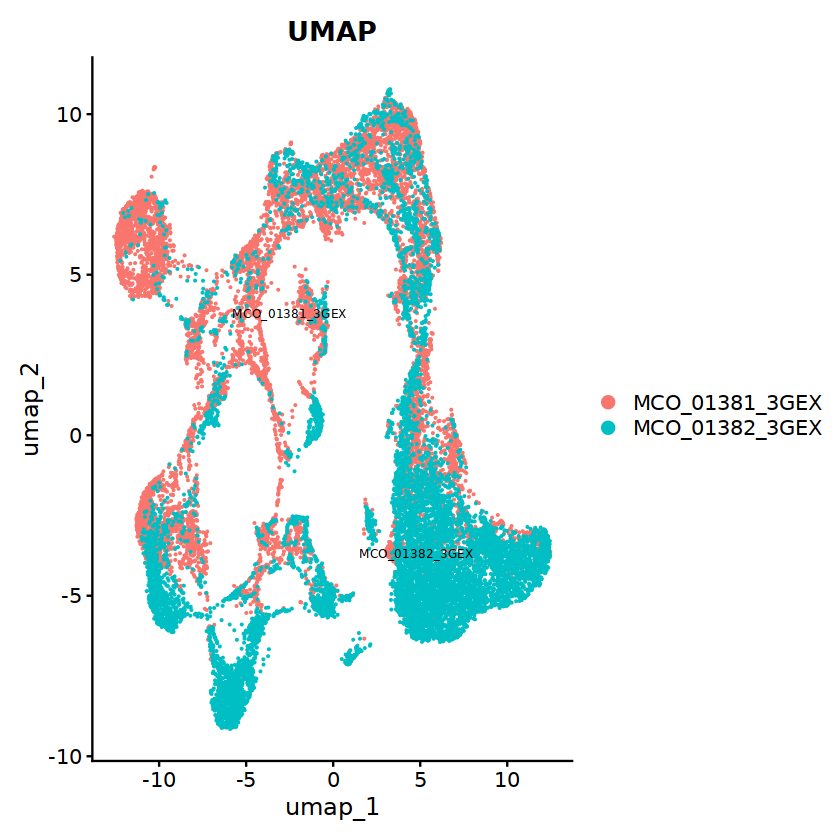

In [9]:
p3 <- DimPlot(adata, reduction = "umap", group.by = "orig.ident", label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("UMAP")
p3

In [10]:
## Graph UMAP by CellTypist_label_filtered

setwd(path_graphs)
png(file='UMAP_by_sample.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

png 
  2

## UMAP by Seurat clusters

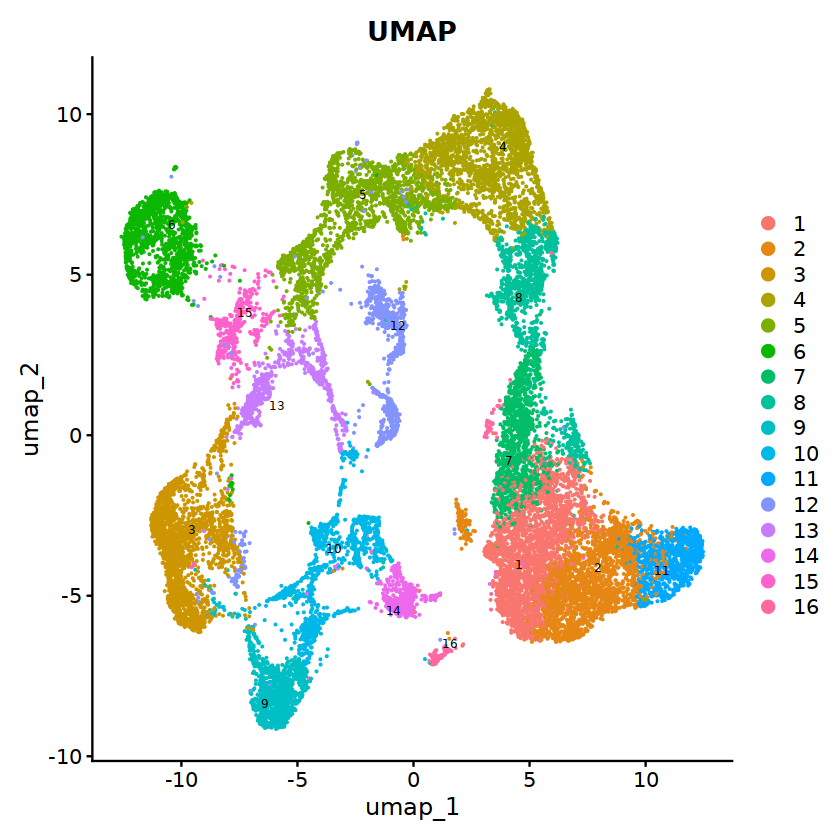

In [11]:
p3 <- DimPlot(adata, reduction = "umap", group.by = "seurat_clusters", label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("UMAP")
p3

In [12]:
## Graph UMAP by CellTypist_label_filtered

setwd(path_graphs)
png(file='UMAP_by_seurat_clusters.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

png 
  2

# Read Alsinet cell typist prediction

In [13]:
setwd("/group/soranzo/manuel.tardaguila/2026_Ditadi_test/CellTypist/")

In [14]:
cell_typist<-read.csv(file="Alsinet_celltypist_prediction.csv")

In [15]:
#str(cell_typist)
str(row.names(cell_typist))
row.names(cell_typist)<-cell_typist$X


 chr [1:19792] "1" "2" "3" "4" "5" "6" "7" "8" "9" "10" "11" "12" "13" "14" ...


In [16]:
str(row.names(cell_typist))

 chr [1:19792] "1" "2" "3" "4" "5" "6" "7" "8" "9" "10" "11" "12" "13" "14" ...


In [17]:
colnames(cell_typist)

[1] "cell_barcode"           "orig.ident"             "nCount_RNA"            
 [4] "nFeature_RNA"           "nCount_RNA_raw"         "nFeature_RNA_raw"      
 [7] "percent.mt"             "scDblFinder.class"      "scDblFinder.score"     
[10] "scDblFinder.weighted"   "scDblFinder.cxds_score" "Diff"                  
[13] "nCount_SCT"             "nFeature_SCT"           "SCT_snn_res.2"         
[16] "seurat_clusters"        "SCT_snn_res.0.5"        "n_counts"              
[19] "predicted_labels"       "conf_score"

In [18]:
cell_typist_subset<-cell_typist[,c(which(colnames(cell_typist) %in% c("predicted_labels","conf_score")))]

In [19]:
str(cell_typist_subset)
str(row.names(cell_typist_subset))

'data.frame':	19792 obs. of  2 variables:
 $ predicted_labels: chr  "PrimitiveStreak" "NeutrophilMyeloidProgenitor" "NeutrophilMyeloidProgenitor" "NeutrophilMyeloidProgenitor" ...
 $ conf_score      : num  0.95094 0.99986 0.00444 0.87522 0.99843 ...
 chr [1:19792] "1" "2" "3" "4" "5" "6" "7" "8" "9" "10" "11" "12" "13" "14" ...


## Add the metadata to the Seurat object

In [20]:
adata <- AddMetaData(
  object = adata,
  metadata = cell_typist_subset$predicted_labels,
  col.name = 'CellTypist_label_Alsinet'
)

In [21]:
adata <- AddMetaData(
  object = adata,
  metadata = cell_typist_subset$conf_score,
  col.name = 'CellTypist_conf_score_Alsinet'
)

## UMAPS of Alsinet

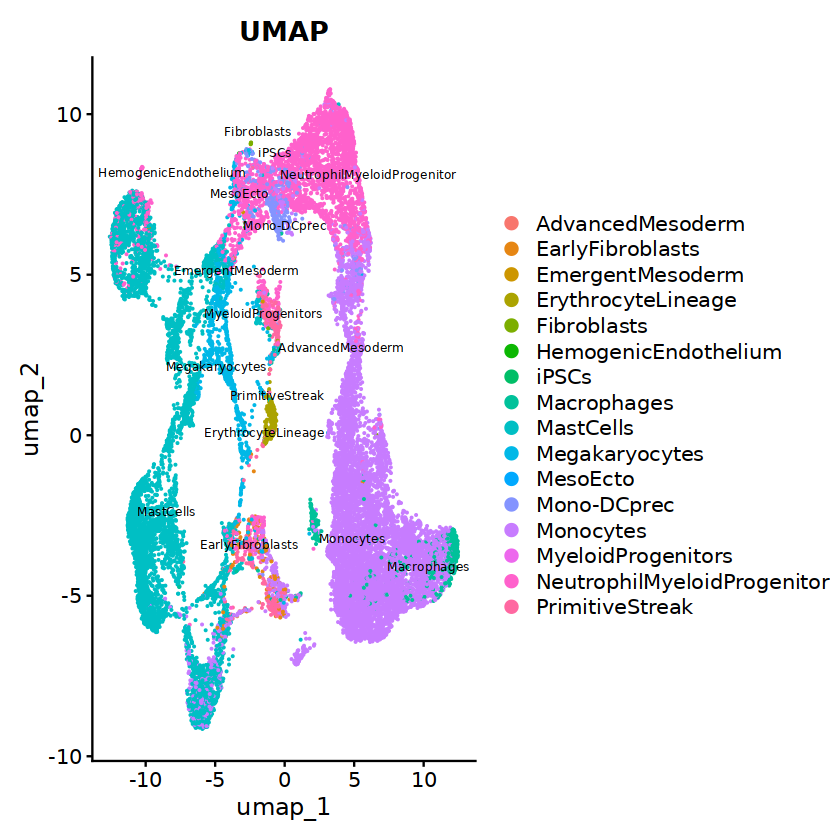

In [22]:
p3 <- DimPlot(adata, reduction = "umap", group.by = "CellTypist_label_Alsinet", label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("UMAP")
p3

In [23]:
## Graph UMAP by CellTypist_label_filtered

setwd(path_graphs)
png(file='UMAP_by_CellTypist_label_Alsinet.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

png 
  2

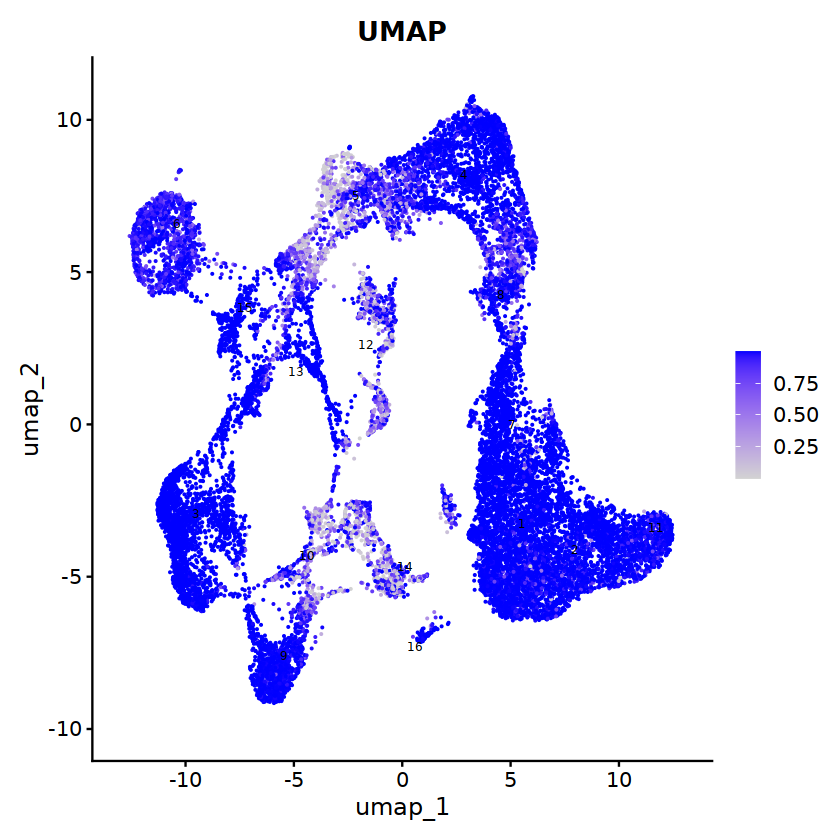

In [24]:
## Graph UMAP by CellTypist_conf_score

p3 <- FeaturePlot(adata, reduction = "umap", 
              features = "CellTypist_conf_score_Alsinet", 
              label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("UMAP")

p3



In [25]:
setwd(path_graphs)
png(file='UMAP_by_CellTypist_label_Alsinet_CONF_SCORE.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

png 
  2

## Barplot of clusters

In [26]:
met<-adata[[]]

In [27]:
colnames(met)

[1] "orig.ident"                    "nCount_RNA"                   
 [3] "nFeature_RNA"                  "nCount_RNA_raw"               
 [5] "nFeature_RNA_raw"              "percent.mt"                   
 [7] "scDblFinder.class"             "scDblFinder.score"            
 [9] "scDblFinder.weighted"          "scDblFinder.cxds_score"       
[11] "Diff"                          "nCount_SCT"                   
[13] "nFeature_SCT"                  "SCT_snn_res.2"                
[15] "seurat_clusters"               "SCT_snn_res.0.5"              
[17] "integrated_snn_res.0.5"        "CellTypist_label_Alsinet"     
[19] "CellTypist_conf_score_Alsinet"

In [28]:
met.dt<-data.table(met,key=c("seurat_clusters","CellTypist_label_Alsinet",'orig.ident'))

In [29]:
#str(met.dt)

In [30]:
Freq.table<-as.data.frame(met.dt[,.(Freq=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.table

In [31]:
met.dt<-data.table(met, key=c("seurat_clusters",'orig.ident'))
Freq.TOTAL<-as.data.frame(met.dt[,.(TOTAL=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.TOTAL

In [32]:
Freq.table<-merge(Freq.table,
                  Freq.TOTAL,
                  by=c("seurat_clusters",'orig.ident'))
Freq.table$Perc<-round((100*(Freq.table$Freq/Freq.table$TOTAL)),2)

#Freq.table

In [33]:
str(Freq.table)

'data.frame':	125 obs. of  6 variables:
 $ seurat_clusters         : Factor w/ 16 levels "1","2","3","4",..: 1 1 1 1 1 10 10 10 10 10 ...
 $ orig.ident              : chr  "MCO_01381_3GEX" "MCO_01382_3GEX" "MCO_01382_3GEX" "MCO_01382_3GEX" ...
 $ CellTypist_label_Alsinet: chr  "Monocytes" "EarlyFibroblasts" "Macrophages" "Monocytes" ...
 $ Freq                    : int  408 1 13 2121 2 1 79 55 21 1 ...
 $ TOTAL                   : int  408 2137 2137 2137 2137 478 478 478 478 478 ...
 $ Perc                    : num  100 0.05 0.61 99.25 0.09 ...


In [34]:
summary(Freq.table$TOTAL)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   17.0   319.0   503.0   668.6   771.0  2137.0 

In [35]:
met.dt<-data.table(met, key=c("CellTypist_label_Alsinet"))
Freq.table_CT_annotation<-as.data.frame(met.dt[,.(Freq_CellTypist_label_Alsinet=.N),by=key(met.dt)], stringsAsFactors=F)



In [36]:
str(Freq.table_CT_annotation)

'data.frame':	16 obs. of  2 variables:
 $ CellTypist_label_Alsinet     : chr  "AdvancedMesoderm" "EarlyFibroblasts" "EmergentMesoderm" "ErythrocyteLineage" ...
 $ Freq_CellTypist_label_Alsinet: int  3 193 3 221 10 13 573 5353 911 1 ...


### Filter x axis by frequency

In [37]:
Freq.table_filtered<-Freq.table[which(Freq.table$TOTAL >= 100),]


str(Freq.table_filtered)

'data.frame':	115 obs. of  6 variables:
 $ seurat_clusters         : Factor w/ 16 levels "1","2","3","4",..: 1 1 1 1 1 10 10 10 10 10 ...
 $ orig.ident              : chr  "MCO_01381_3GEX" "MCO_01382_3GEX" "MCO_01382_3GEX" "MCO_01382_3GEX" ...
 $ CellTypist_label_Alsinet: chr  "Monocytes" "EarlyFibroblasts" "Macrophages" "Monocytes" ...
 $ Freq                    : int  408 1 13 2121 2 1 79 55 21 1 ...
 $ TOTAL                   : int  408 2137 2137 2137 2137 478 478 478 478 478 ...
 $ Perc                    : num  100 0.05 0.61 99.25 0.09 ...


In [38]:
vector_colors_CellTypist_label_Alsinet<-c(brewer.pal(9, "Set1"),brewer.pal(12, "Set3"),"white")


length(vector_colors_CellTypist_label_Alsinet)

[1] 22

-------------------------------------->	0 25 50 75 100


Warning message:
"The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead."
Warning message:
"The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead."


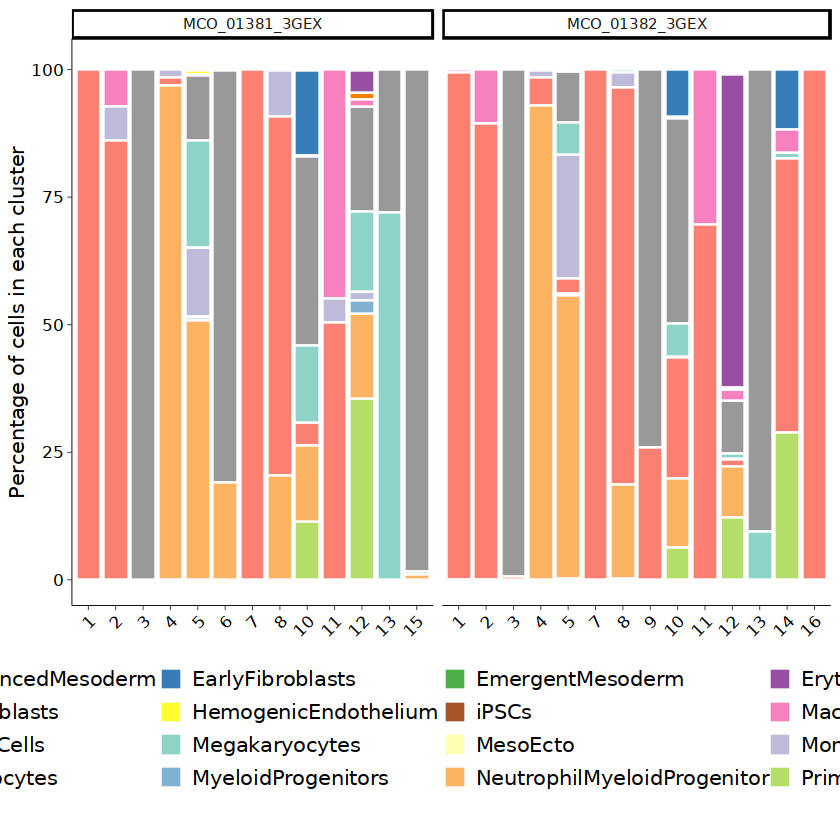

In [39]:
 #### Stacked Graph ---------------
  
  breaks.Rank<-(seq(0,100,by=25))
  labels.Rank<-as.character(breaks.Rank)
  
  cat("-------------------------------------->\t")
  cat(sprintf(as.character(labels.Rank)))
  cat("\n")
  
  
  stacked_barplot<-ggplot(data= Freq.table_filtered,
           aes(x=seurat_clusters, y=Perc, fill=CellTypist_label_Alsinet)) +
    geom_bar(stat="identity",colour='white')+
    scale_y_continuous(name=paste("Percentage of cells in each cluster",sep=" "),breaks=breaks.Rank,labels=labels.Rank,
                       limits=c(breaks.Rank[1],breaks.Rank[length(breaks.Rank)]+1))+
    scale_fill_manual(values=vector_colors_CellTypist_label_Alsinet,
                      drop=F,
                      name="Alsinet model")

stacked_barplot<-stacked_barplot+
    theme_cowplot(font_size = 2)+
    facet_grid(. ~ orig.ident, scales='free_x', space='free_x', switch="y")+   
    scale_x_discrete(name="Seurat clusters", drop=TRUE)+
    theme( strip.background = element_blank(),
           strip.placement = "outside",
           strip.text = element_text(size=12),
           panel.spacing = unit(0.2, "lines"),
           panel.background=element_rect(fill="white"),
           panel.border=element_rect(colour="white",size=0,5),
           panel.grid.major = element_blank(),
           panel.grid.minor = element_blank())+
        theme_classic()+
            theme(axis.title.y=element_text(size=12, color="black", family="sans"),
                  axis.title.x=element_blank(),
                  axis.text.y=element_text(angle=0,size=10, color="black", family="sans"),
                  axis.text.x=element_text(angle=45,size=10,vjust=1,hjust=1,color="black", family="sans"),
                  axis.line.x = element_line(size = 0.2),
                  axis.ticks.x = element_line(size = 0.2),
                  axis.ticks.y = element_line(size = 0.2),
                  axis.line.y = element_line(size = 0.2))+
            theme(legend.title = element_blank(),
                  legend.text = element_text(size=12, color="black", family="sans"),
                  legend.key.size = unit(0.5, 'cm'), #change legend key size
                  legend.key.height = unit(0.5, 'cm'), #change legend key height
                  legend.key.width = unit(0.5, 'cm'), #change legend key width
                  legend.position="bottom")+
            guides(fill=guide_legend(nrow=5,byrow=TRUE))



stacked_barplot
  




  

In [40]:
setwd(path_graphs)

svgname<-paste("Stacked_barplot_Alsinet_vs_cluster",".svg",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= stacked_barplot,
         device="svg", width =13, height = 13)
}

## Violin plot of confidence score

In [41]:
str(met)

'data.frame':	19792 obs. of  19 variables:
 $ orig.ident                   : chr  "MCO_01381_3GEX" "MCO_01381_3GEX" "MCO_01381_3GEX" "MCO_01381_3GEX" ...
 $ nCount_RNA                   : num  1049 44869 56017 39429 48620 ...
 $ nFeature_RNA                 : int  568 7042 7955 6674 7389 560 8540 7653 5794 8386 ...
 $ nCount_RNA_raw               : num  1904 45083 56246 39640 48809 ...
 $ nFeature_RNA_raw             : int  1119 7052 7965 6682 7389 1152 8561 7665 5820 8401 ...
 $ percent.mt                   : num  0.477 4.656 3.951 4.053 4.967 ...
 $ scDblFinder.class            : chr  "singlet" "singlet" "singlet" "singlet" ...
 $ scDblFinder.score            : num  0.0247 0.1318 0.104 0.2349 0.2692 ...
 $ scDblFinder.weighted         : num  0.0396 0.1741 0.1656 0.4283 0.3483 ...
 $ scDblFinder.cxds_score       : num  0 0.0908 0.0352 0.0746 0.1804 ...
 $ Diff                         : chr  "Diff_Ditadi_wt" "Diff_Ditadi_wt" "Diff_Ditadi_wt" "Diff_Ditadi_wt" ...
 $ nCount_SCT          

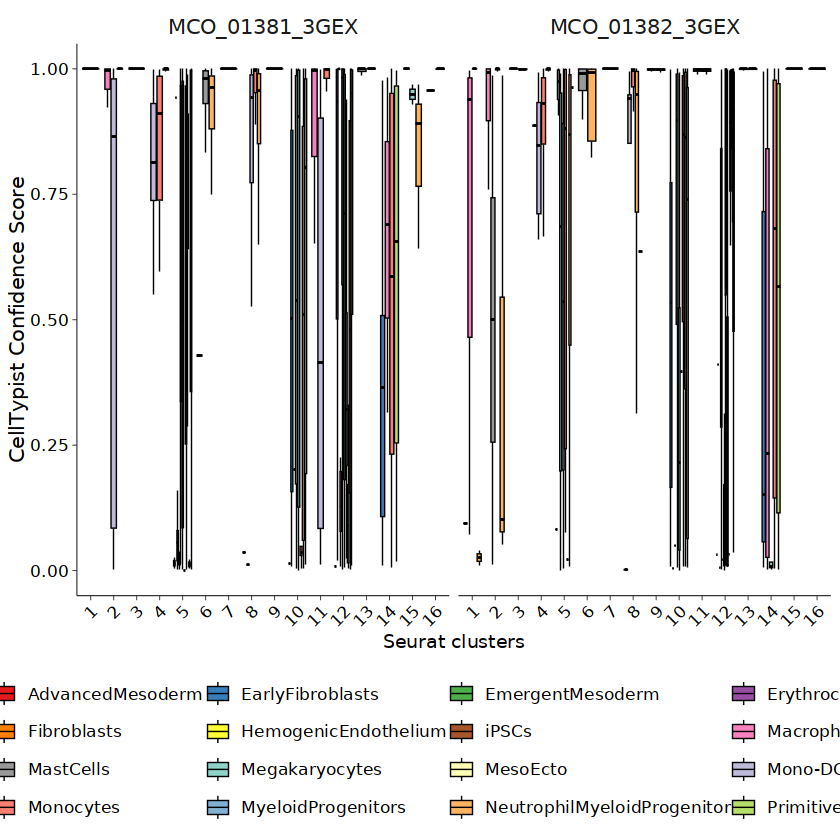

In [42]:
library(ggplot2)
library(RColorBrewer)

# 1. Define color vector
vector_colors_CellTypist_label_Alsinet <- c(brewer.pal(9, "Set1"), brewer.pal(12, "Set3"), "grey80")

# 2. Build the Plot (Boxplot only)
boxplot_only_plot <- ggplot(met, aes(x = seurat_clusters, 
                                     y = CellTypist_conf_score_Alsinet, 
                                     fill = CellTypist_label_Alsinet)) +
  
  # Grouped boxplots without outliers
  # width = 0.7 gives them more horizontal space since the violins are gone
  geom_boxplot(width = 0.7, 
               color = "black", 
               linewidth = 0.3,
               outlier.shape = NA, 
               position = position_dodge(width = 0.8)) +
  
  # Grid by sample
  facet_grid(. ~ orig.ident, scales = 'free_x', space = 'free_x') +
  
  # Manual colors and drop unused labels from legend
  scale_fill_manual(values = vector_colors_CellTypist_label_Alsinet,
                    drop = TRUE, 
                    name = "Alsinet label") +
  
  # Ensure X-axis drops empty clusters
  scale_x_discrete(name = "Seurat clusters", drop = TRUE) +
  
  # Standardize Y-axis for confidence scores
  scale_y_continuous(limits = c(0, 1)) +
  
  labs(y = "CellTypist Confidence Score") +
  
  # Applying your requested theme styling
  theme_classic() +
  theme(
    strip.background = element_blank(),
    strip.text = element_text(size = 12),
    axis.title.y = element_text(size = 12, color = "black"),
    axis.text.y = element_text(size = 10, color = "black"),
    axis.text.x = element_text(angle = 45, size = 10, vjust = 1, hjust = 1, color = "black"),
    axis.line = element_line(linewidth = 0.2),
    axis.ticks = element_line(linewidth = 0.2),
    legend.position = "bottom",
    legend.text = element_text(size = 10),
    legend.title = element_blank()
  ) +
  guides(fill = guide_legend(nrow = 4, byrow = TRUE))

print(boxplot_only_plot)

In [43]:
setwd(path_graphs)

svgname<-paste("Violin_plot_Alsinet_vs_cluster",".svg",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= boxplot_only_plot,
         device="svg", width =13, height = 13)
}

## Dot plot

In [44]:
summary_means <- met %>%
  group_by(orig.ident, seurat_clusters, CellTypist_label_Alsinet) %>%
  dplyr::summarise(
    mean_conf_score = mean(CellTypist_conf_score_Alsinet, na.rm = TRUE),
    cell_count = n(),
    .groups = "drop" # This replaces the need for ungroup()
  )

# View results
head(summary_means)

orig.ident,seurat_clusters,CellTypist_label_Alsinet,mean_conf_score,cell_count
<chr>,<fct>,<chr>,<dbl>,<int>
MCO_01381_3GEX,1,Monocytes,0.9987449,408
MCO_01381_3GEX,2,Macrophages,0.8690259,17
MCO_01381_3GEX,2,Mono-DCprec,0.6212228,16
MCO_01381_3GEX,2,Monocytes,0.9723654,205
MCO_01381_3GEX,3,MastCells,0.9999982,1201
MCO_01381_3GEX,4,Mono-DCprec,0.7854562,23


In [45]:
library(dplyr)

summary_final <- summary_means %>%
  # 1. Force the columns to characters to be safe
  mutate(
    seurat_clusters = as.character(seurat_clusters),
    orig.ident = as.character(orig.ident)
  ) %>%
  # 2. Use the explicit dplyr group_by
  dplyr::group_by(orig.ident, seurat_clusters) %>%
  # 3. Use the explicit dplyr mutate
  dplyr::mutate(
    cluster_total = sum(cell_count),
    percentage = (cell_count / cluster_total) * 100
  ) %>%
  dplyr::ungroup()

# VERIFICATION: This should now show ~1296 for Cluster 0


In [46]:
summary_final %>% filter(seurat_clusters == "0")
cat("\n")

summary_final %>% filter(seurat_clusters == "2")
cat("\n")

orig.ident,seurat_clusters,CellTypist_label_Alsinet,mean_conf_score,cell_count,cluster_total,percentage
<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>


orig.ident,seurat_clusters,CellTypist_label_Alsinet,mean_conf_score,cell_count,cluster_total,percentage
<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>
MCO_01381_3GEX,2,Macrophages,0.8690259,17,238,7.14285714
MCO_01381_3GEX,2,Mono-DCprec,0.6212228,16,238,6.72268908
MCO_01381_3GEX,2,Monocytes,0.9723654,205,238,86.13445378
MCO_01382_3GEX,2,Macrophages,0.8657632,213,2028,10.50295858
MCO_01382_3GEX,2,MastCells,0.4995260,2,2028,0.09861933
MCO_01382_3GEX,2,Monocytes,0.9827022,1810,2028,89.25049310
MCO_01382_3GEX,2,NeutrophilMyeloidProgenitor,0.3806488,3,2028,0.14792899


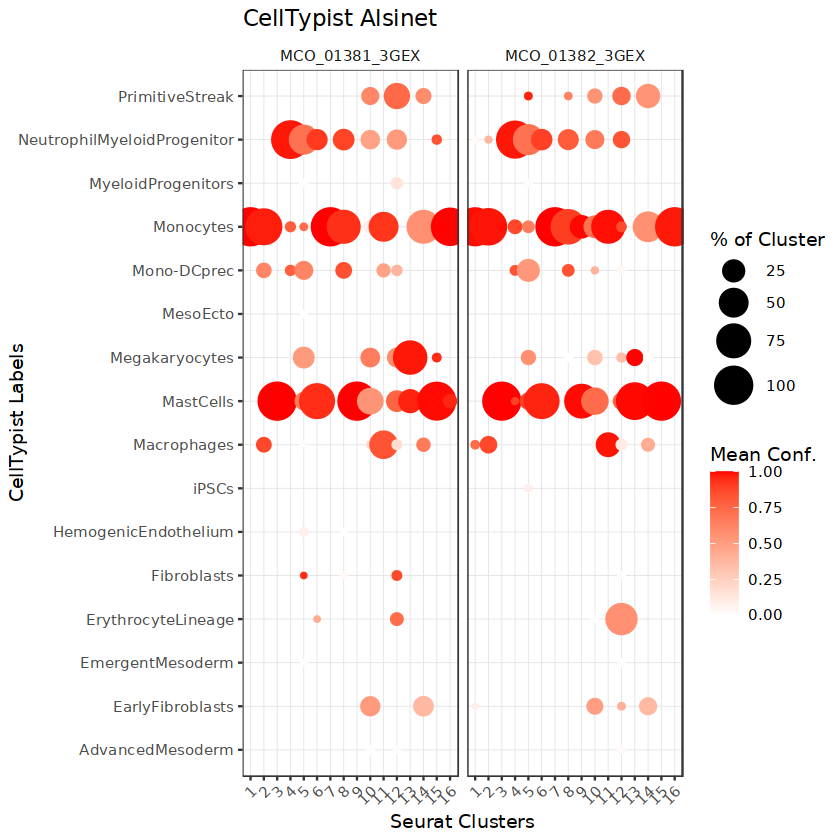

In [47]:

# 1. Sort clusters numerically for the X-axis
summary_final$seurat_clusters <- factor(summary_final$seurat_clusters, 
                                        levels = sort(as.numeric(unique(summary_final$seurat_clusters))))

# 2. Create the Dot Plot
dotplot_annotation <- ggplot(summary_final, aes(x = seurat_clusters, 
                                                y = CellTypist_label_Alsinet)) +
  # Use geom_point where size and color represent your calculated metrics
  geom_point(aes(size = percentage, color = mean_conf_score)) +
  
  # Set the color gradient from white to red
  # limits c(0,1) ensures the scale is consistent for confidence scores
  scale_color_gradient(low = "white", high = "red", limits = c(0, 1), name = "Mean Conf.") +
  
  # Adjust the size scale to make dots visible but not overlapping
  scale_size_continuous(range = c(1, 10), name = "% of Cluster") +
  
  # Grid by sample
  facet_grid(. ~ orig.ident, scales = "free_x", space = "free_x") +
  
  # Clean theme and labels
  theme_bw() +
  labs(
    title = "CellTypist Alsinet",
    x = "Seurat Clusters",
    y = "CellTypist Labels"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major = element_line(linewidth = 0.2, color = "grey90"),
    strip.background = element_blank(),
    legend.position = "right"
  )

# Display plot
dotplot_annotation

In [48]:
setwd(path_graphs)

svgname<-paste("Dot_plot_Alsinet_vs_cluster",".svg",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= dotplot_annotation,
         device="svg", width =13, height = 13)
}

# Read FBMA cell typist prediction

In [49]:
setwd("/group/soranzo/manuel.tardaguila/2026_Ditadi_test/CellTypist/")

In [50]:
cell_typist<-read.csv(file="FBMA_celltypist_prediction.csv")

In [51]:
#str(cell_typist)
str(row.names(cell_typist))
row.names(cell_typist)<-cell_typist$X


 chr [1:19792] "1" "2" "3" "4" "5" "6" "7" "8" "9" "10" "11" "12" "13" "14" ...


In [52]:
str(row.names(cell_typist))

 chr [1:19792] "1" "2" "3" "4" "5" "6" "7" "8" "9" "10" "11" "12" "13" "14" ...


In [53]:
colnames(cell_typist)

[1] "cell_barcode"           "orig.ident"             "nCount_RNA"            
 [4] "nFeature_RNA"           "nCount_RNA_raw"         "nFeature_RNA_raw"      
 [7] "percent.mt"             "scDblFinder.class"      "scDblFinder.score"     
[10] "scDblFinder.weighted"   "scDblFinder.cxds_score" "Diff"                  
[13] "nCount_SCT"             "nFeature_SCT"           "SCT_snn_res.2"         
[16] "seurat_clusters"        "SCT_snn_res.0.5"        "n_counts"              
[19] "predicted_labels"       "conf_score"

In [54]:
cell_typist_subset<-cell_typist[,c(which(colnames(cell_typist) %in% c("predicted_labels","conf_score")))]

In [55]:
str(cell_typist_subset)
str(row.names(cell_typist_subset))

'data.frame':	19792 obs. of  2 variables:
 $ predicted_labels: chr  "late erythroid" "GMP" "DC3" "promyelocyte" ...
 $ conf_score      : num  0.416 0.291 0.187 0.484 0.568 ...
 chr [1:19792] "1" "2" "3" "4" "5" "6" "7" "8" "9" "10" "11" "12" "13" "14" ...


## Add the metadata to the Seurat object

In [56]:
adata <- AddMetaData(
  object = adata,
  metadata = cell_typist_subset$predicted_labels,
  col.name = 'CellTypist_label_FBMA'
)

In [57]:
adata <- AddMetaData(
  object = adata,
  metadata = cell_typist_subset$conf_score,
  col.name = 'CellTypist_conf_score_FBMA'
)

## UMAPS of FBMA

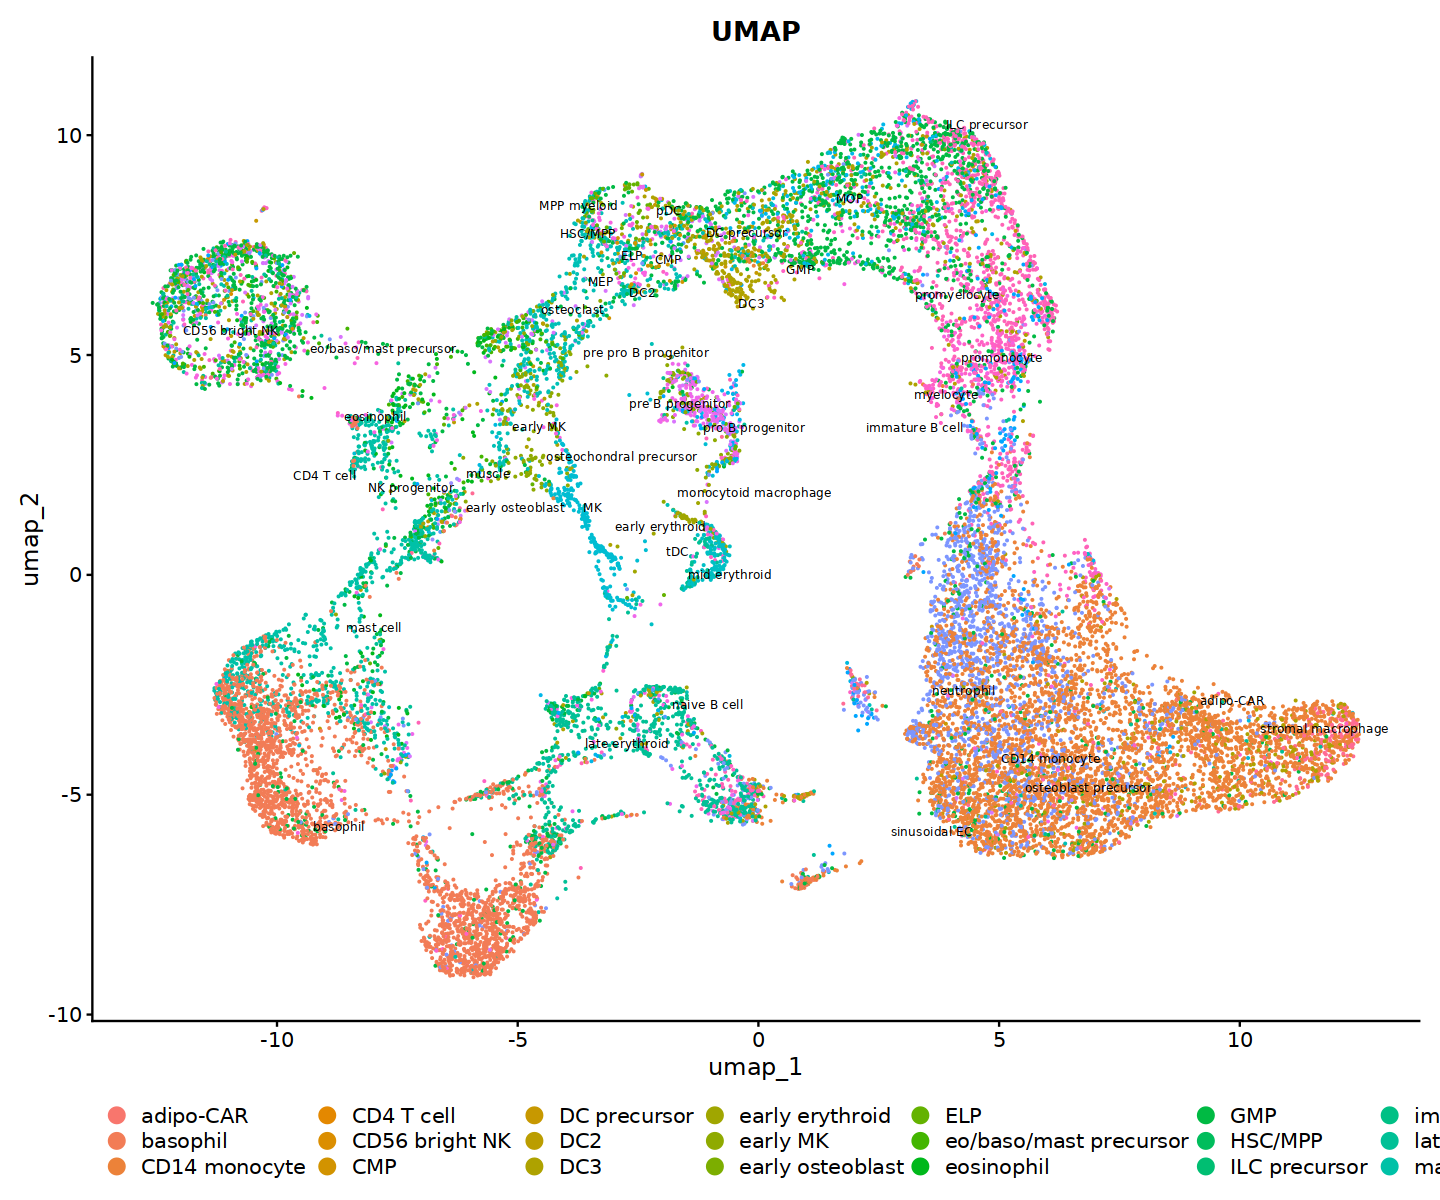

In [58]:
# Increase width to give the legend space at the bottom
options(repr.plot.width = 12, repr.plot.height = 10)

p3 <- DimPlot(adata, 
              reduction = "umap", 
              group.by = "CellTypist_label_FBMA", 
              label = TRUE, 
              label.size = 2.5, 
              repel = TRUE) + 
      ggtitle("UMAP") +
      theme(legend.position = "bottom") +
      # Optional: arrange legend in rows if you have many labels
      guides(color = guide_legend(nrow = 3, override.aes = list(size = 4)))

p3

In [59]:
## Graph UMAP by CellTypist_label_filtered

setwd(path_graphs)
png(file='UMAP_by_CellTypist_label_FBMA.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

Warning message:
"ggrepel: 3 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


png 
  2

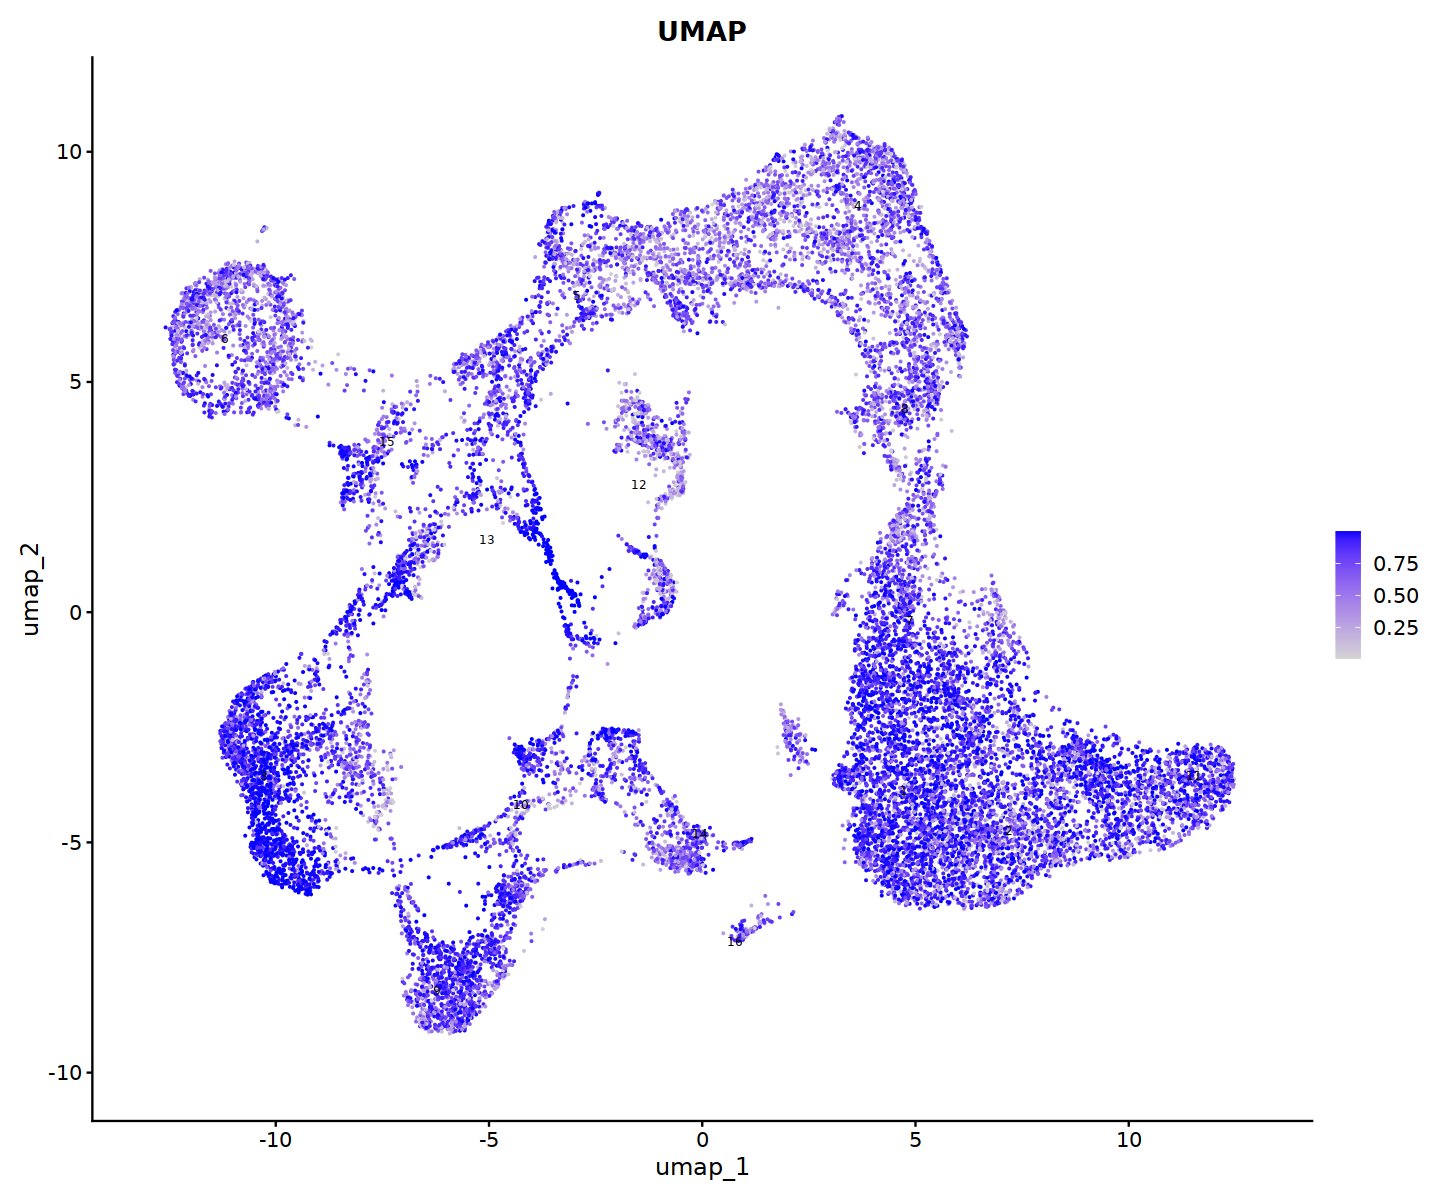

In [60]:
## Graph UMAP by CellTypist_conf_score

p3 <- FeaturePlot(adata, reduction = "umap", 
              features = "CellTypist_conf_score_FBMA", 
              label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("UMAP")

p3



In [61]:
setwd(path_graphs)
png(file='UMAP_by_CellTypist_label_FBMA_CONF_SCORE.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

png 
  2

## Barplot of clusters

In [62]:
met<-adata[[]]

In [63]:
colnames(met)

[1] "orig.ident"                    "nCount_RNA"                   
 [3] "nFeature_RNA"                  "nCount_RNA_raw"               
 [5] "nFeature_RNA_raw"              "percent.mt"                   
 [7] "scDblFinder.class"             "scDblFinder.score"            
 [9] "scDblFinder.weighted"          "scDblFinder.cxds_score"       
[11] "Diff"                          "nCount_SCT"                   
[13] "nFeature_SCT"                  "SCT_snn_res.2"                
[15] "seurat_clusters"               "SCT_snn_res.0.5"              
[17] "integrated_snn_res.0.5"        "CellTypist_label_Alsinet"     
[19] "CellTypist_conf_score_Alsinet" "CellTypist_label_FBMA"        
[21] "CellTypist_conf_score_FBMA"

In [64]:
met.dt<-data.table(met,key=c("seurat_clusters","CellTypist_label_FBMA",'orig.ident'))

In [65]:
#str(met.dt)

In [66]:
Freq.table<-as.data.frame(met.dt[,.(Freq=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.table

In [67]:
met.dt<-data.table(met, key=c("seurat_clusters",'orig.ident'))
Freq.TOTAL<-as.data.frame(met.dt[,.(TOTAL=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.TOTAL

In [68]:
Freq.table<-merge(Freq.table,
                  Freq.TOTAL,
                  by=c("seurat_clusters",'orig.ident'))
Freq.table$Perc<-round((100*(Freq.table$Freq/Freq.table$TOTAL)),2)

#Freq.table

In [69]:
str(Freq.table)

'data.frame':	514 obs. of  6 variables:
 $ seurat_clusters      : Factor w/ 16 levels "1","2","3","4",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ orig.ident           : chr  "MCO_01381_3GEX" "MCO_01381_3GEX" "MCO_01381_3GEX" "MCO_01381_3GEX" ...
 $ CellTypist_label_FBMA: chr  "CD14 monocyte" "neutrophil" "stromal macrophage" "DC3" ...
 $ Freq                 : int  254 144 2 2 1 1 3 1 5 3 ...
 $ TOTAL                : int  408 408 408 408 408 408 408 408 2137 2137 ...
 $ Perc                 : num  62.25 35.29 0.49 0.49 0.25 ...


In [70]:
summary(Freq.table$TOTAL)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   17.0   319.0   529.0   711.5  1201.0  2137.0 

In [71]:
met.dt<-data.table(met, key=c("CellTypist_label_FBMA"))
Freq.table_CT_annotation<-as.data.frame(met.dt[,.(Freq_CellTypist_label_FBMA=.N),by=key(met.dt)], stringsAsFactors=F)



In [72]:
str(Freq.table_CT_annotation)

'data.frame':	44 obs. of  2 variables:
 $ CellTypist_label_FBMA     : chr  "CD14 monocyte" "CD4 T cell" "CD56 bright NK" "CMP" ...
 $ Freq_CellTypist_label_FBMA: int  4501 1 10 29 40 156 970 97 2397 14 ...


### Filter x axis by frequency

In [73]:
Freq.table_filtered<-Freq.table[which(Freq.table$TOTAL >= 100),]


str(Freq.table_filtered)

'data.frame':	467 obs. of  6 variables:
 $ seurat_clusters      : Factor w/ 16 levels "1","2","3","4",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ orig.ident           : chr  "MCO_01381_3GEX" "MCO_01381_3GEX" "MCO_01381_3GEX" "MCO_01381_3GEX" ...
 $ CellTypist_label_FBMA: chr  "CD14 monocyte" "neutrophil" "stromal macrophage" "DC3" ...
 $ Freq                 : int  254 144 2 2 1 1 3 1 5 3 ...
 $ TOTAL                : int  408 408 408 408 408 408 408 408 2137 2137 ...
 $ Perc                 : num  62.25 35.29 0.49 0.49 0.25 ...


In [74]:
# 1. Identify how many unique labels you actually have
n_labels <- length(unique(Freq.table_filtered$CellTypist_label_FBMA))

# 2. Create a large palette (42+ colors)
# We combine several palettes and use colorRampPalette to fill the gaps
get_big_palette <- colorRampPalette(c(
  brewer.pal(9, "Set1"), 
  brewer.pal(12, "Set3"), 
  brewer.pal(8, "Dark2"),
  brewer.pal(8, "Accent")
))

vector_colors_CellTypist_label_FBMA <- get_big_palette(n_labels)

-------------------------------------->	0 25 50 75 100


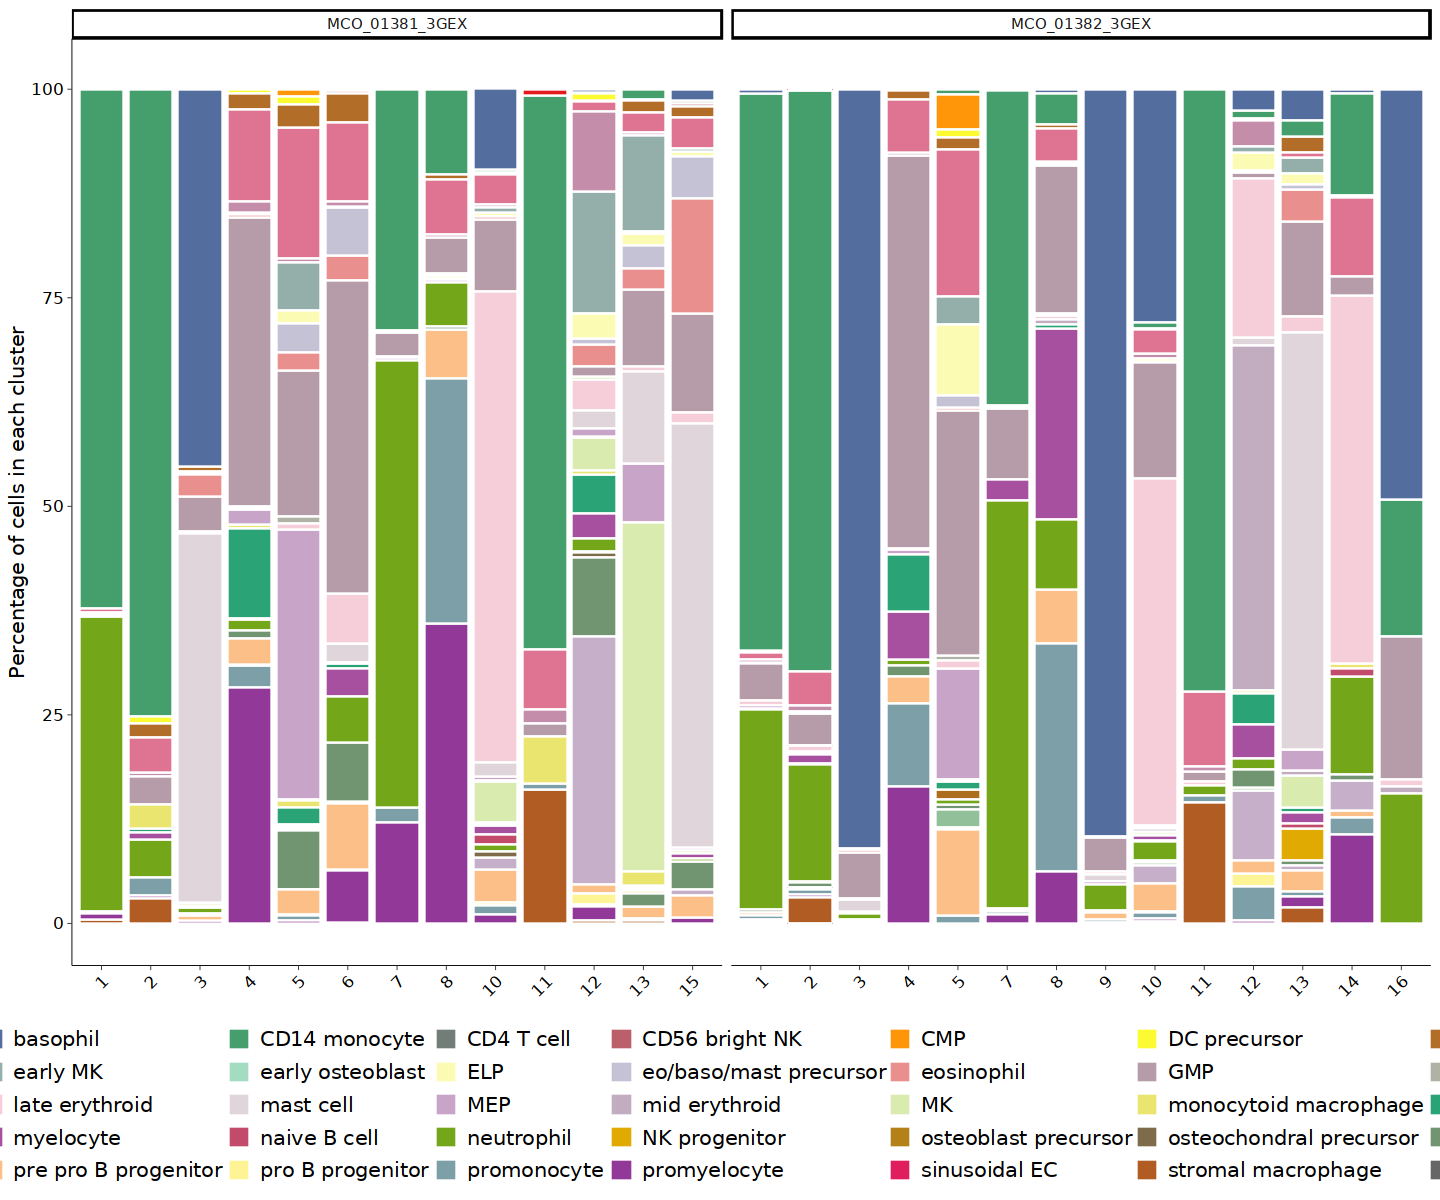

In [75]:
 #### Stacked Graph ---------------
  
  breaks.Rank<-(seq(0,100,by=25))
  labels.Rank<-as.character(breaks.Rank)
  
  cat("-------------------------------------->\t")
  cat(sprintf(as.character(labels.Rank)))
  cat("\n")
  
  
  stacked_barplot<-ggplot(data= Freq.table_filtered,
           aes(x=seurat_clusters, y=Perc, fill=CellTypist_label_FBMA)) +
    geom_bar(stat="identity",colour='white')+
    scale_y_continuous(name=paste("Percentage of cells in each cluster",sep=" "),breaks=breaks.Rank,labels=labels.Rank,
                       limits=c(breaks.Rank[1],breaks.Rank[length(breaks.Rank)]+1))+
    scale_fill_manual(values=vector_colors_CellTypist_label_FBMA,
                      drop=F,
                      name="Alsinet model")

stacked_barplot<-stacked_barplot+
    theme_cowplot(font_size = 2)+
    facet_grid(. ~ orig.ident, scales='free_x', space='free_x', switch="y")+   
    scale_x_discrete(name="Seurat clusters", drop=TRUE)+
    theme( strip.background = element_blank(),
           strip.placement = "outside",
           strip.text = element_text(size=12),
           panel.spacing = unit(0.2, "lines"),
           panel.background=element_rect(fill="white"),
           panel.border=element_rect(colour="white",size=0,5),
           panel.grid.major = element_blank(),
           panel.grid.minor = element_blank())+
        theme_classic()+
            theme(axis.title.y=element_text(size=12, color="black", family="sans"),
                  axis.title.x=element_blank(),
                  axis.text.y=element_text(angle=0,size=10, color="black", family="sans"),
                  axis.text.x=element_text(angle=45,size=10,vjust=1,hjust=1,color="black", family="sans"),
                  axis.line.x = element_line(size = 0.2),
                  axis.ticks.x = element_line(size = 0.2),
                  axis.ticks.y = element_line(size = 0.2),
                  axis.line.y = element_line(size = 0.2))+
            theme(legend.title = element_blank(),
                  legend.text = element_text(size=12, color="black", family="sans"),
                  legend.key.size = unit(0.5, 'cm'), #change legend key size
                  legend.key.height = unit(0.5, 'cm'), #change legend key height
                  legend.key.width = unit(0.5, 'cm'), #change legend key width
                  legend.position="bottom")+
            guides(fill=guide_legend(nrow=5,byrow=TRUE))



stacked_barplot
  




  

In [76]:
setwd(path_graphs)

svgname<-paste("Stacked_barplot_FBMA_vs_cluster",".svg",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= stacked_barplot,
         device="svg", width =13, height = 13)
}

## Violin plot of confidence score

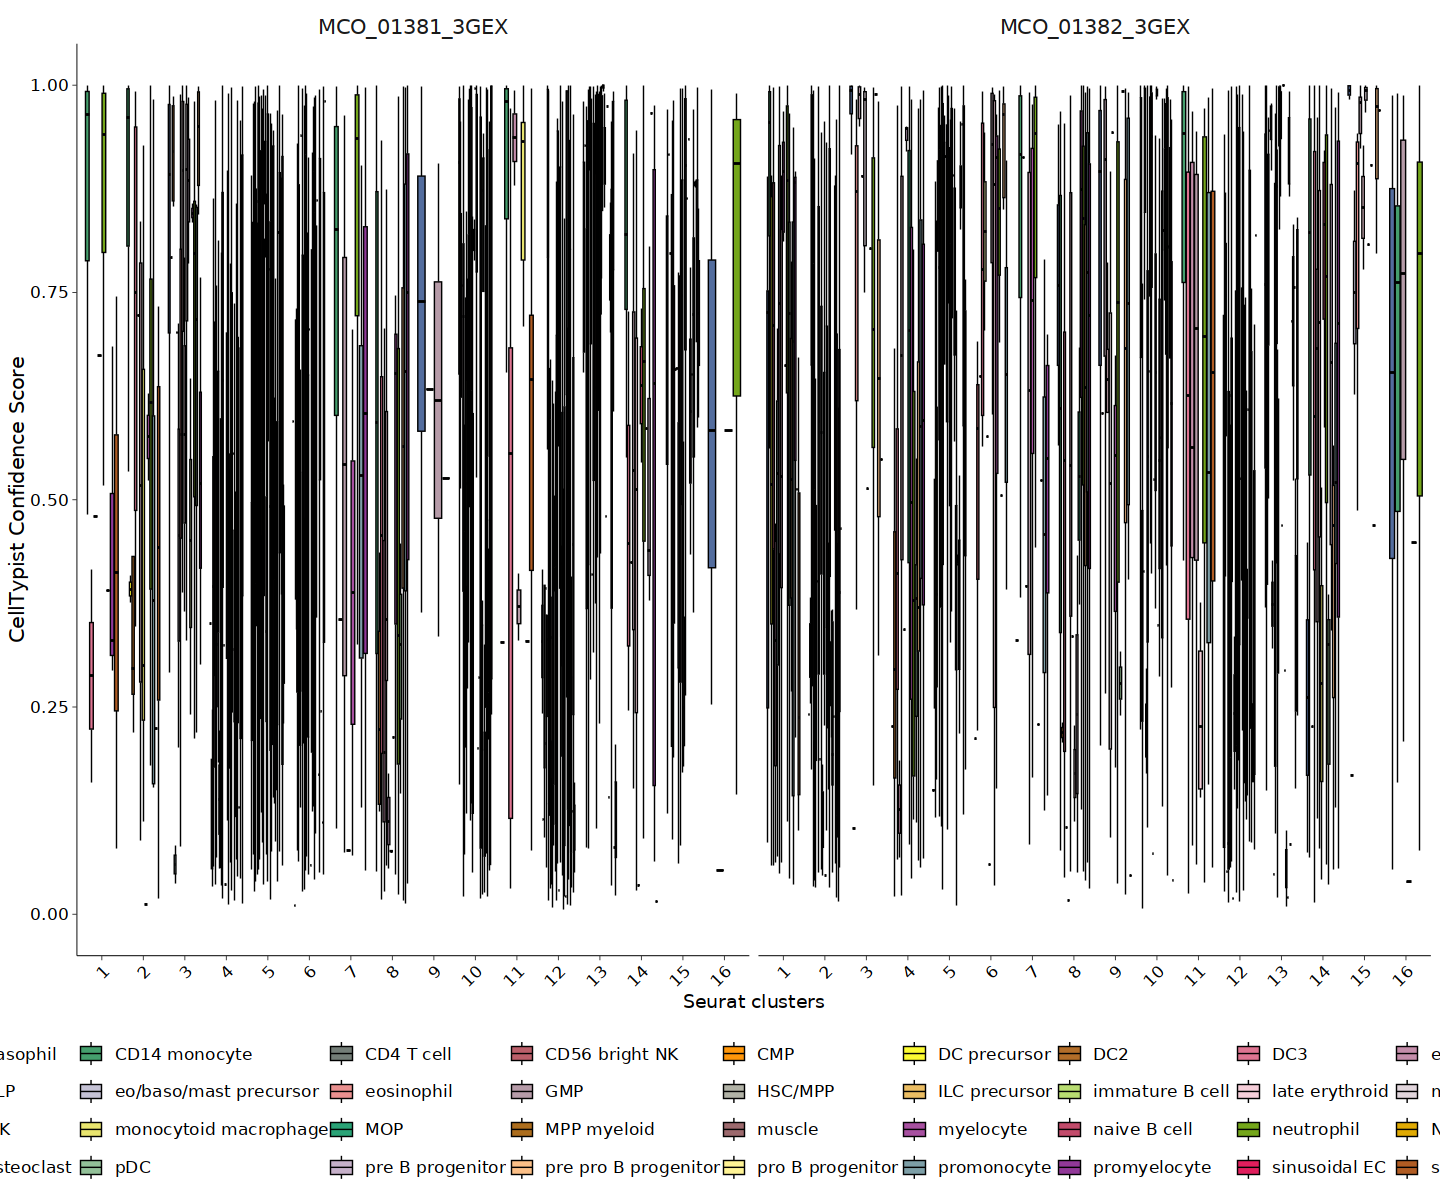

In [77]:
library(ggplot2)
library(RColorBrewer)

# 1. Define color vector
vector_colors_CellTypist_label_FBMA <- vector_colors_CellTypist_label_FBMA

# 2. Build the Plot (Boxplot only)
boxplot_only_plot <- ggplot(met, aes(x = seurat_clusters, 
                                     y = CellTypist_conf_score_FBMA, 
                                     fill = CellTypist_label_FBMA)) +
  
  # Grouped boxplots without outliers
  # width = 0.7 gives them more horizontal space since the violins are gone
  geom_boxplot(width = 0.7, 
               color = "black", 
               linewidth = 0.3,
               outlier.shape = NA, 
               position = position_dodge(width = 0.8)) +
  
  # Grid by sample
  facet_grid(. ~ orig.ident, scales = 'free_x', space = 'free_x') +
  
  # Manual colors and drop unused labels from legend
  scale_fill_manual(values = vector_colors_CellTypist_label_FBMA,
                    drop = TRUE, 
                    name = "Alsinet label") +
  
  # Ensure X-axis drops empty clusters
  scale_x_discrete(name = "Seurat clusters", drop = TRUE) +
  
  # Standardize Y-axis for confidence scores
  scale_y_continuous(limits = c(0, 1)) +
  
  labs(y = "CellTypist Confidence Score") +
  
  # Applying your requested theme styling
  theme_classic() +
  theme(
    strip.background = element_blank(),
    strip.text = element_text(size = 12),
    axis.title.y = element_text(size = 12, color = "black"),
    axis.text.y = element_text(size = 10, color = "black"),
    axis.text.x = element_text(angle = 45, size = 10, vjust = 1, hjust = 1, color = "black"),
    axis.line = element_line(linewidth = 0.2),
    axis.ticks = element_line(linewidth = 0.2),
    legend.position = "bottom",
    legend.text = element_text(size = 10),
    legend.title = element_blank()
  ) +
  guides(fill = guide_legend(nrow = 4, byrow = TRUE))

print(boxplot_only_plot)

In [78]:
setwd(path_graphs)

svgname<-paste("Violin_plot_FBMA_vs_cluster",".svg",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= boxplot_only_plot,
         device="svg", width =13, height = 13)
}

## Dot plot

In [79]:
summary_means <- met %>%
  group_by(orig.ident, seurat_clusters, CellTypist_label_FBMA) %>%
  dplyr::summarise(
    mean_conf_score = mean(CellTypist_conf_score_FBMA, na.rm = TRUE),
    cell_count = n(),
    .groups = "drop" # This replaces the need for ungroup()
  )

# View results
head(summary_means)

orig.ident,seurat_clusters,CellTypist_label_FBMA,mean_conf_score,cell_count
<chr>,<fct>,<chr>,<dbl>,<int>
MCO_01381_3GEX,1,CD14 monocyte,0.8372781,254
MCO_01381_3GEX,1,DC3,0.2875869,2
MCO_01381_3GEX,1,GMP,0.6735811,1
MCO_01381_3GEX,1,early erythroid,0.4800150,1
MCO_01381_3GEX,1,neutrophil,0.8465422,144
MCO_01381_3GEX,1,pre pro B progenitor,0.3903471,1


In [80]:
library(dplyr)

summary_final <- summary_means %>%
  # 1. Force the columns to characters to be safe
  mutate(
    seurat_clusters = as.character(seurat_clusters),
    orig.ident = as.character(orig.ident)
  ) %>%
  # 2. Use the explicit dplyr group_by
  dplyr::group_by(orig.ident, seurat_clusters) %>%
  # 3. Use the explicit dplyr mutate
  dplyr::mutate(
    cluster_total = sum(cell_count),
    percentage = (cell_count / cluster_total) * 100
  ) %>%
  dplyr::ungroup()

# VERIFICATION: This should now show ~1296 for Cluster 0


In [81]:
summary_final %>% filter(seurat_clusters == "0")
cat("\n")

summary_final %>% filter(seurat_clusters == "2")
cat("\n")

orig.ident,seurat_clusters,CellTypist_label_FBMA,mean_conf_score,cell_count,cluster_total,percentage
<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>


orig.ident,seurat_clusters,CellTypist_label_FBMA,mean_conf_score,cell_count,cluster_total,percentage
<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>
MCO_01381_3GEX,2,CD14 monocyte,0.86424534,179,238,75.21008403
MCO_01381_3GEX,2,DC precursor,0.39227993,2,238,0.84033613
MCO_01381_3GEX,2,DC2,0.40049875,4,238,1.68067227
MCO_01381_3GEX,2,DC3,0.70871944,10,238,4.20168067
MCO_01381_3GEX,2,GMP,0.50573630,8,238,3.36134454
MCO_01381_3GEX,2,MOP,0.01232303,1,238,0.42016807
MCO_01381_3GEX,2,early erythroid,0.72236947,1,238,0.42016807
MCO_01381_3GEX,2,monocytoid macrophage,0.44596783,7,238,2.94117647
MCO_01381_3GEX,2,myelocyte,0.57573884,2,238,0.84033613


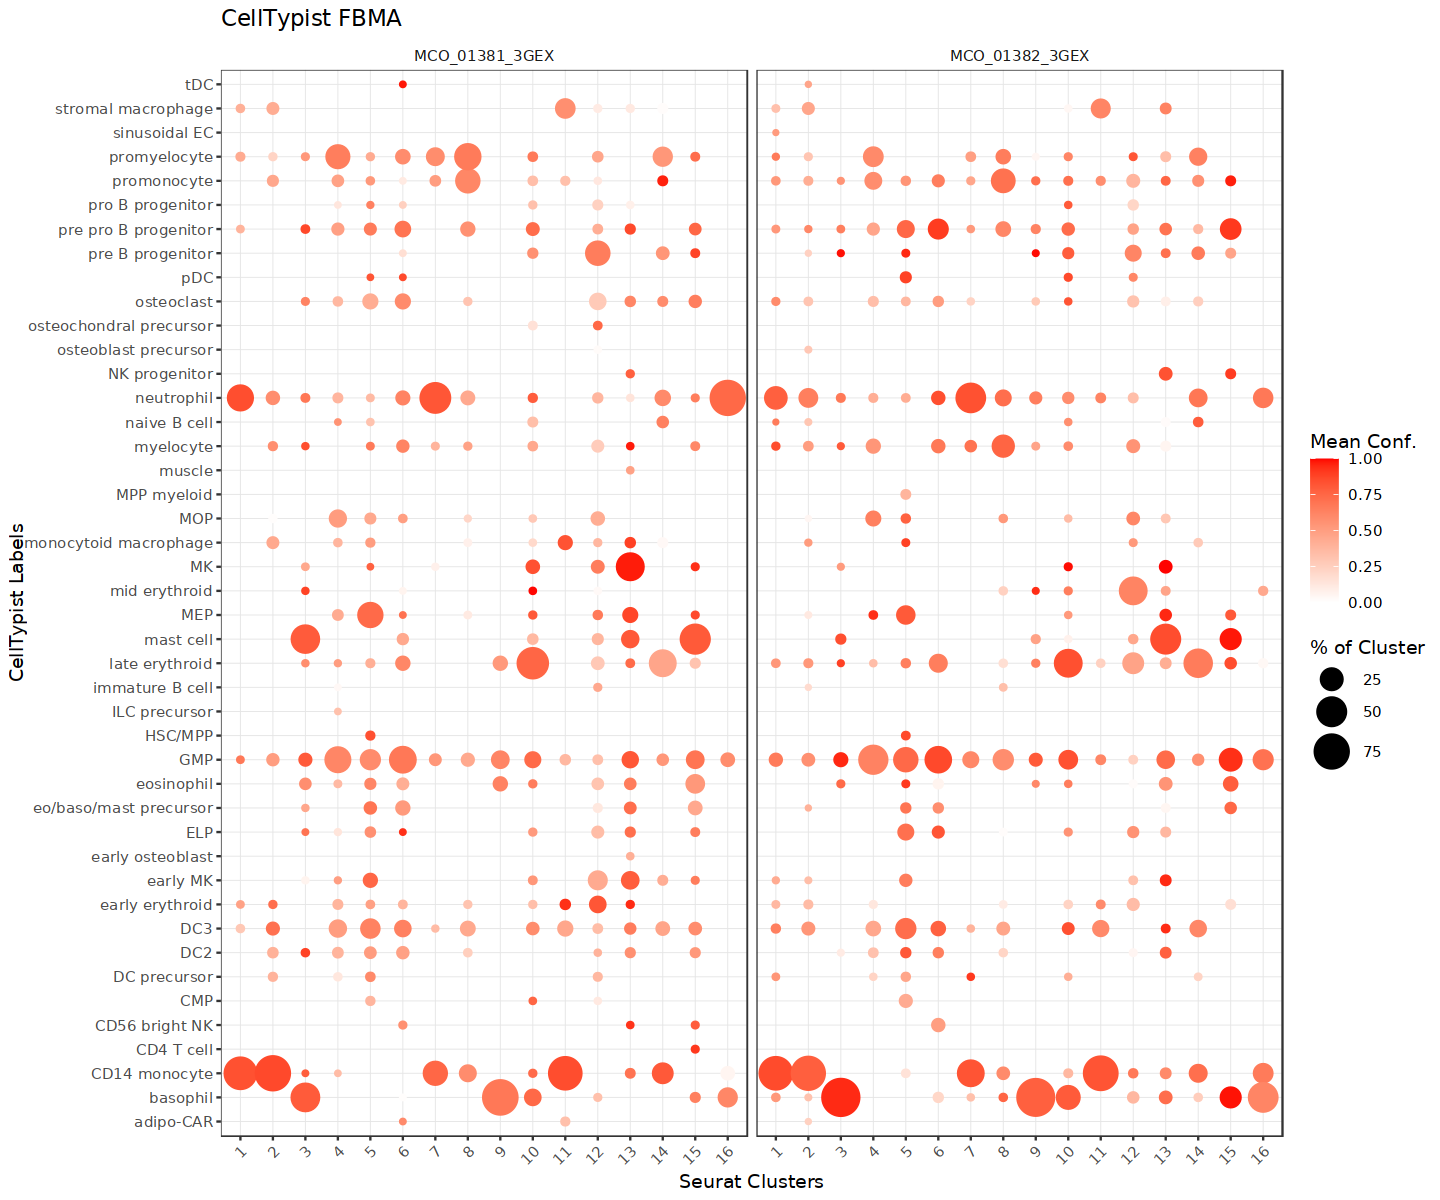

In [82]:

# 1. Sort clusters numerically for the X-axis
summary_final$seurat_clusters <- factor(summary_final$seurat_clusters, 
                                        levels = sort(as.numeric(unique(summary_final$seurat_clusters))))

# 2. Create the Dot Plot
dotplot_annotation <- ggplot(summary_final, aes(x = seurat_clusters, 
                                                y = CellTypist_label_FBMA)) +
  # Use geom_point where size and color represent your calculated metrics
  geom_point(aes(size = percentage, color = mean_conf_score)) +
  
  # Set the color gradient from white to red
  # limits c(0,1) ensures the scale is consistent for confidence scores
  scale_color_gradient(low = "white", high = "red", limits = c(0, 1), name = "Mean Conf.") +
  
  # Adjust the size scale to make dots visible but not overlapping
  scale_size_continuous(range = c(1, 10), name = "% of Cluster") +
  
  # Grid by sample
  facet_grid(. ~ orig.ident, scales = "free_x", space = "free_x") +
  
  # Clean theme and labels
  theme_bw() +
  labs(
    title = "CellTypist FBMA",
    x = "Seurat Clusters",
    y = "CellTypist Labels"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major = element_line(linewidth = 0.2, color = "grey90"),
    strip.background = element_blank(),
    legend.position = "right"
  )

# Display plot
dotplot_annotation

In [83]:
setwd(path_graphs)

svgname<-paste("Dot_plot_FBMA_vs_cluster",".svg",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= dotplot_annotation,
         device="svg", width =13, height = 13)
}

# Read Immune_ALL_low cell typist prediction

In [84]:
setwd("/group/soranzo/manuel.tardaguila/2026_Ditadi_test/CellTypist/")

In [85]:
cell_typist<-read.csv(file="Immune_ALL_low_celltypist_prediction.csv")

In [86]:
#str(cell_typist)
str(row.names(cell_typist))
row.names(cell_typist)<-cell_typist$X


 chr [1:19792] "1" "2" "3" "4" "5" "6" "7" "8" "9" "10" "11" "12" "13" "14" ...


In [87]:
str(row.names(cell_typist))

 chr [1:19792] "1" "2" "3" "4" "5" "6" "7" "8" "9" "10" "11" "12" "13" "14" ...


In [88]:
colnames(cell_typist)

[1] "cell_barcode"           "orig.ident"             "nCount_RNA"            
 [4] "nFeature_RNA"           "nCount_RNA_raw"         "nFeature_RNA_raw"      
 [7] "percent.mt"             "scDblFinder.class"      "scDblFinder.score"     
[10] "scDblFinder.weighted"   "scDblFinder.cxds_score" "Diff"                  
[13] "nCount_SCT"             "nFeature_SCT"           "SCT_snn_res.2"         
[16] "seurat_clusters"        "SCT_snn_res.0.5"        "n_counts"              
[19] "predicted_labels"       "conf_score"

In [89]:
cell_typist_subset<-cell_typist[,c(which(colnames(cell_typist) %in% c("predicted_labels","conf_score")))]

In [90]:
str(cell_typist_subset)
str(row.names(cell_typist_subset))

'data.frame':	19792 obs. of  2 variables:
 $ predicted_labels: chr  "Double-positive thymocytes" "Neutrophil-myeloid progenitor" "HSC/MPP" "Neutrophil-myeloid progenitor" ...
 $ conf_score      : num  0.245 1 0.969 0.995 0.998 ...
 chr [1:19792] "1" "2" "3" "4" "5" "6" "7" "8" "9" "10" "11" "12" "13" "14" ...


## Add the metadata to the Seurat object

In [91]:
adata <- AddMetaData(
  object = adata,
  metadata = cell_typist_subset$predicted_labels,
  col.name = 'CellTypist_label_Immune_ALL_low'
)

In [92]:
adata <- AddMetaData(
  object = adata,
  metadata = cell_typist_subset$conf_score,
  col.name = 'CellTypist_conf_score_Immune_ALL_low'
)

## UMAPS of Immune_ALL_low

Warning message:
"ggrepel: 21 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


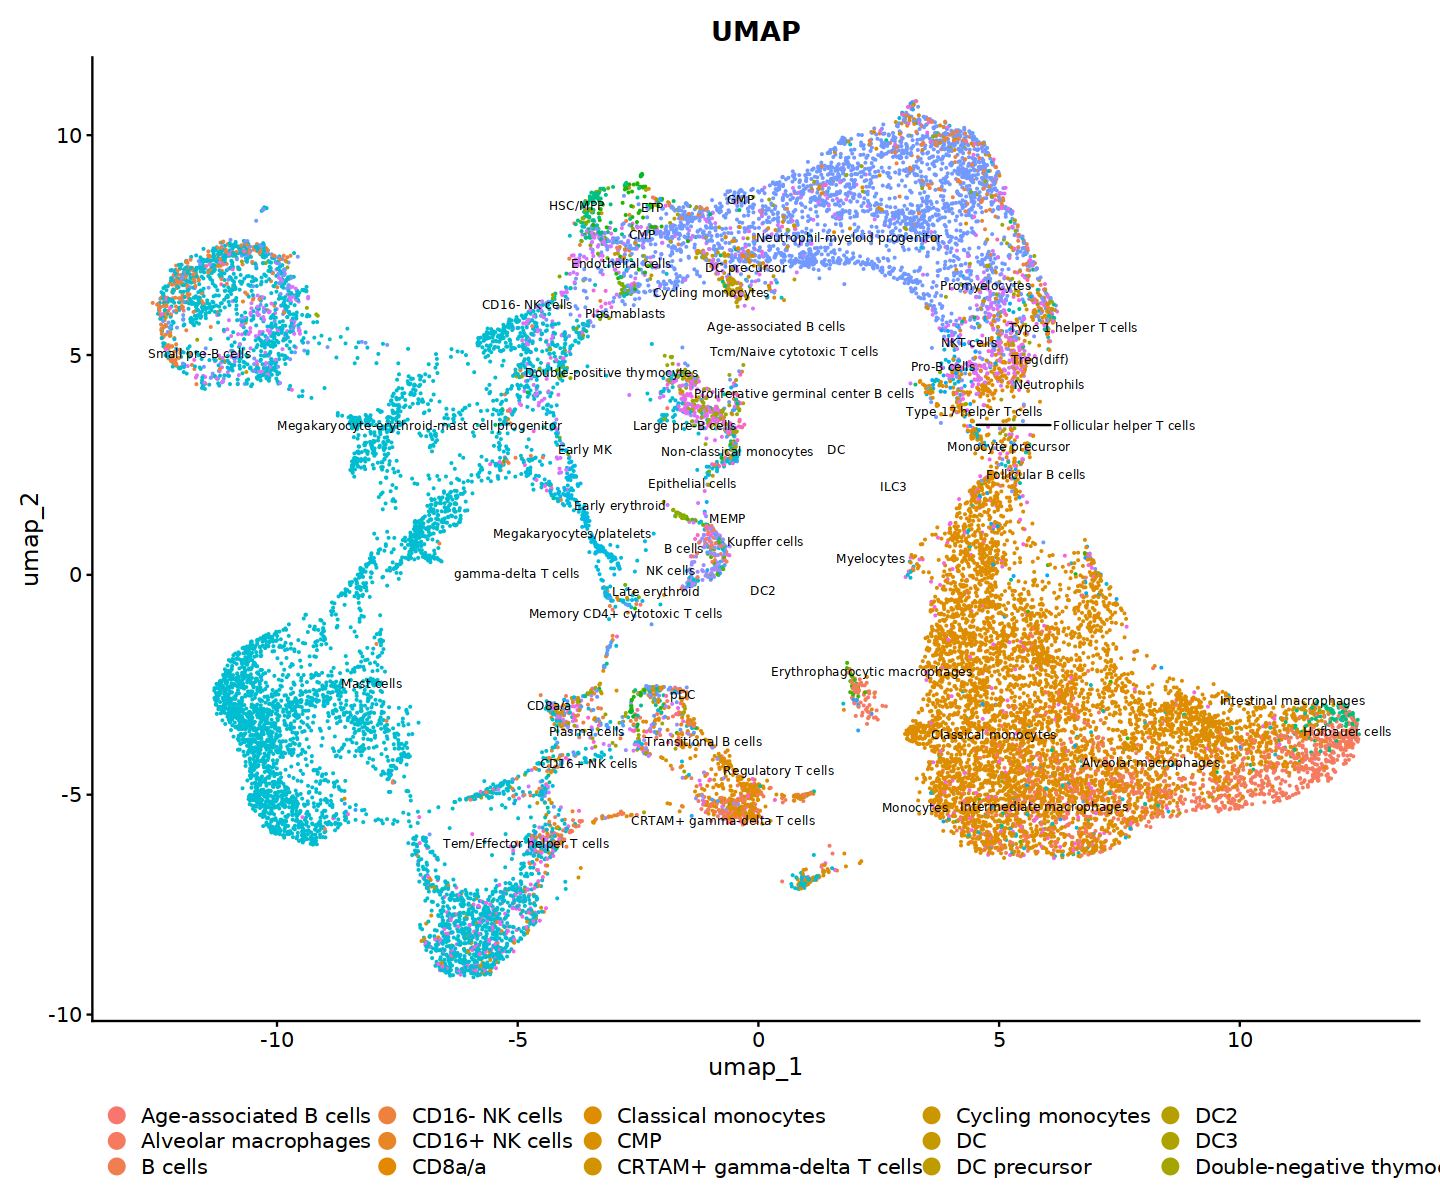

In [93]:
# Increase width to give the legend space at the bottom
options(repr.plot.width = 12, repr.plot.height = 10)

p3 <- DimPlot(adata, 
              reduction = "umap", 
              group.by = "CellTypist_label_Immune_ALL_low", 
              label = TRUE, 
              label.size = 2.5, 
              repel = TRUE) + 
      ggtitle("UMAP") +
      theme(legend.position = "bottom") +
      # Optional: arrange legend in rows if you have many labels
      guides(color = guide_legend(nrow = 3, override.aes = list(size = 4)))

p3

In [94]:
## Graph UMAP by CellTypist_label_filtered

setwd(path_graphs)
png(file='UMAP_by_CellTypist_label_Immune_ALL_low.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

Warning message:
"ggrepel: 37 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


png 
  2

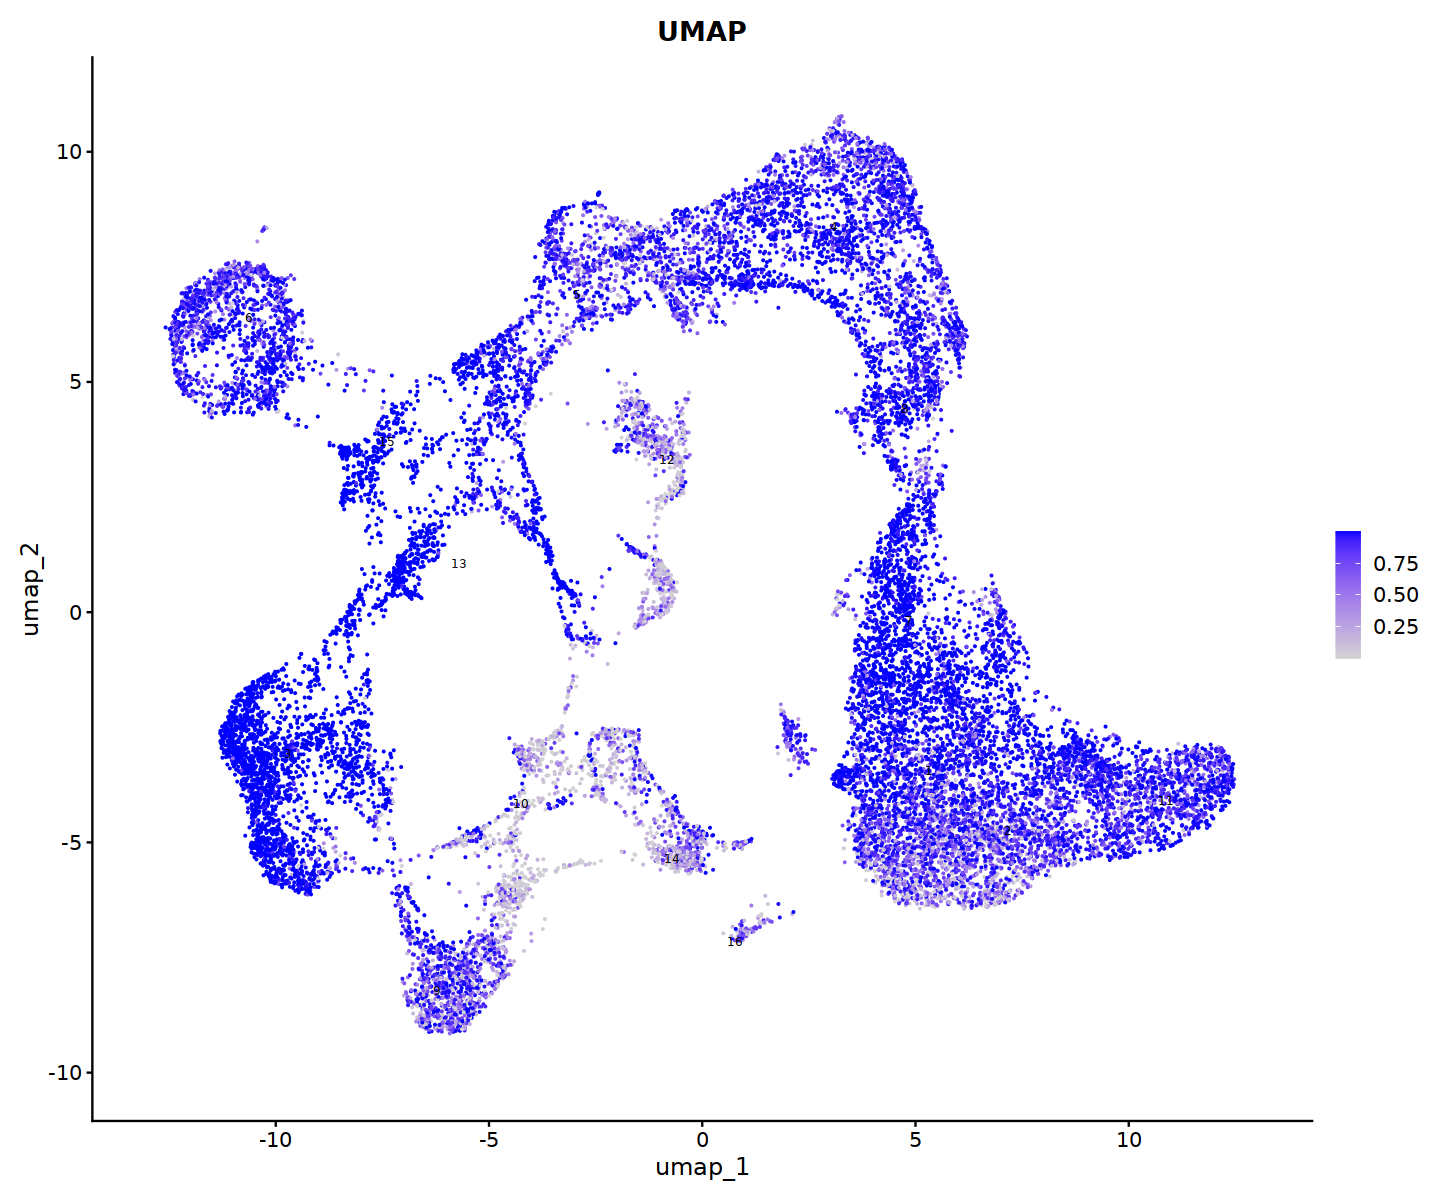

In [95]:
## Graph UMAP by CellTypist_conf_score

p3 <- FeaturePlot(adata, reduction = "umap", 
              features = "CellTypist_conf_score_Immune_ALL_low", 
              label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("UMAP")

p3



In [96]:
setwd(path_graphs)
png(file='UMAP_by_CellTypist_label_Immune_ALL_low_CONF_SCORE.png', width =500, height = 350)
p3  & theme(plot.title = element_text(hjust = 0.5))
dev.off()

png 
  2

## Barplot of clusters

In [97]:
met<-adata[[]]

In [98]:
colnames(met)

[1] "orig.ident"                          
 [2] "nCount_RNA"                          
 [3] "nFeature_RNA"                        
 [4] "nCount_RNA_raw"                      
 [5] "nFeature_RNA_raw"                    
 [6] "percent.mt"                          
 [7] "scDblFinder.class"                   
 [8] "scDblFinder.score"                   
 [9] "scDblFinder.weighted"                
[10] "scDblFinder.cxds_score"              
[11] "Diff"                                
[12] "nCount_SCT"                          
[13] "nFeature_SCT"                        
[14] "SCT_snn_res.2"                       
[15] "seurat_clusters"                     
[16] "SCT_snn_res.0.5"                     
[17] "integrated_snn_res.0.5"              
[18] "CellTypist_label_Alsinet"            
[19] "CellTypist_conf_score_Alsinet"       
[20] "CellTypist_label_FBMA"               
[21] "CellTypist_conf_score_FBMA"          
[22] "CellTypist_label_Immune_ALL_low"     
[23] "CellTypist_conf_score_Immune_ALL_low"

In [99]:
met.dt<-data.table(met,key=c("seurat_clusters","CellTypist_label_Immune_ALL_low",'orig.ident'))

In [100]:
#str(met.dt)

In [101]:
Freq.table<-as.data.frame(met.dt[,.(Freq=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.table

In [102]:
met.dt<-data.table(met, key=c("seurat_clusters",'orig.ident'))
Freq.TOTAL<-as.data.frame(met.dt[,.(TOTAL=.N),by=key(met.dt)], stringsAsFactors=F)
#Freq.TOTAL

In [103]:
Freq.table<-merge(Freq.table,
                  Freq.TOTAL,
                  by=c("seurat_clusters",'orig.ident'))
Freq.table$Perc<-round((100*(Freq.table$Freq/Freq.table$TOTAL)),2)

#Freq.table

In [104]:
str(Freq.table)

'data.frame':	452 obs. of  6 variables:
 $ seurat_clusters                : Factor w/ 16 levels "1","2","3","4",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ orig.ident                     : chr  "MCO_01381_3GEX" "MCO_01381_3GEX" "MCO_01381_3GEX" "MCO_01381_3GEX" ...
 $ CellTypist_label_Immune_ALL_low: chr  "Alveolar macrophages" "Regulatory T cells" "Classical monocytes" "Mast cells" ...
 $ Freq                           : int  4 2 401 1 112 1 1906 1 1 3 ...
 $ TOTAL                          : int  408 408 408 408 2137 2137 2137 2137 2137 2137 ...
 $ Perc                           : num  0.98 0.49 98.28 0.25 5.24 ...


In [105]:
summary(Freq.table$TOTAL)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   17.0   392.0   529.0   717.2   850.0  2137.0 

In [106]:
met.dt<-data.table(met, key=c("CellTypist_label_Immune_ALL_low"))
Freq.table_CT_annotation<-as.data.frame(met.dt[,.(Freq_CellTypist_label_Immune_ALL_low=.N),by=key(met.dt)], stringsAsFactors=F)



In [107]:
str(Freq.table_CT_annotation)

'data.frame':	71 obs. of  2 variables:
 $ CellTypist_label_Immune_ALL_low     : chr  "Age-associated B cells" "Alveolar macrophages" "B cells" "CD16+ NK cells" ...
 $ Freq_CellTypist_label_Immune_ALL_low: int  4 1398 3 53 523 10 7 13 6354 1 ...


### Filter x axis by frequency

In [108]:
Freq.table_filtered<-Freq.table[which(Freq.table$TOTAL >= 100),]


str(Freq.table_filtered)

'data.frame':	431 obs. of  6 variables:
 $ seurat_clusters                : Factor w/ 16 levels "1","2","3","4",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ orig.ident                     : chr  "MCO_01381_3GEX" "MCO_01381_3GEX" "MCO_01381_3GEX" "MCO_01381_3GEX" ...
 $ CellTypist_label_Immune_ALL_low: chr  "Alveolar macrophages" "Regulatory T cells" "Classical monocytes" "Mast cells" ...
 $ Freq                           : int  4 2 401 1 112 1 1906 1 1 3 ...
 $ TOTAL                          : int  408 408 408 408 2137 2137 2137 2137 2137 2137 ...
 $ Perc                           : num  0.98 0.49 98.28 0.25 5.24 ...


In [109]:
# 1. Identify how many unique labels you actually have
n_labels <- length(unique(Freq.table_filtered$CellTypist_label_Immune_ALL_low))

# 2. Create a large palette (42+ colors)
# We combine several palettes and use colorRampPalette to fill the gaps
get_big_palette <- colorRampPalette(c(
  brewer.pal(9, "Set1"), 
  brewer.pal(12, "Set3"), 
  brewer.pal(8, "Dark2"),
  brewer.pal(8, "Accent")
))

vector_colors_CellTypist_label_Immune_ALL_low <- get_big_palette(n_labels)

-------------------------------------->	0 25 50 75 100


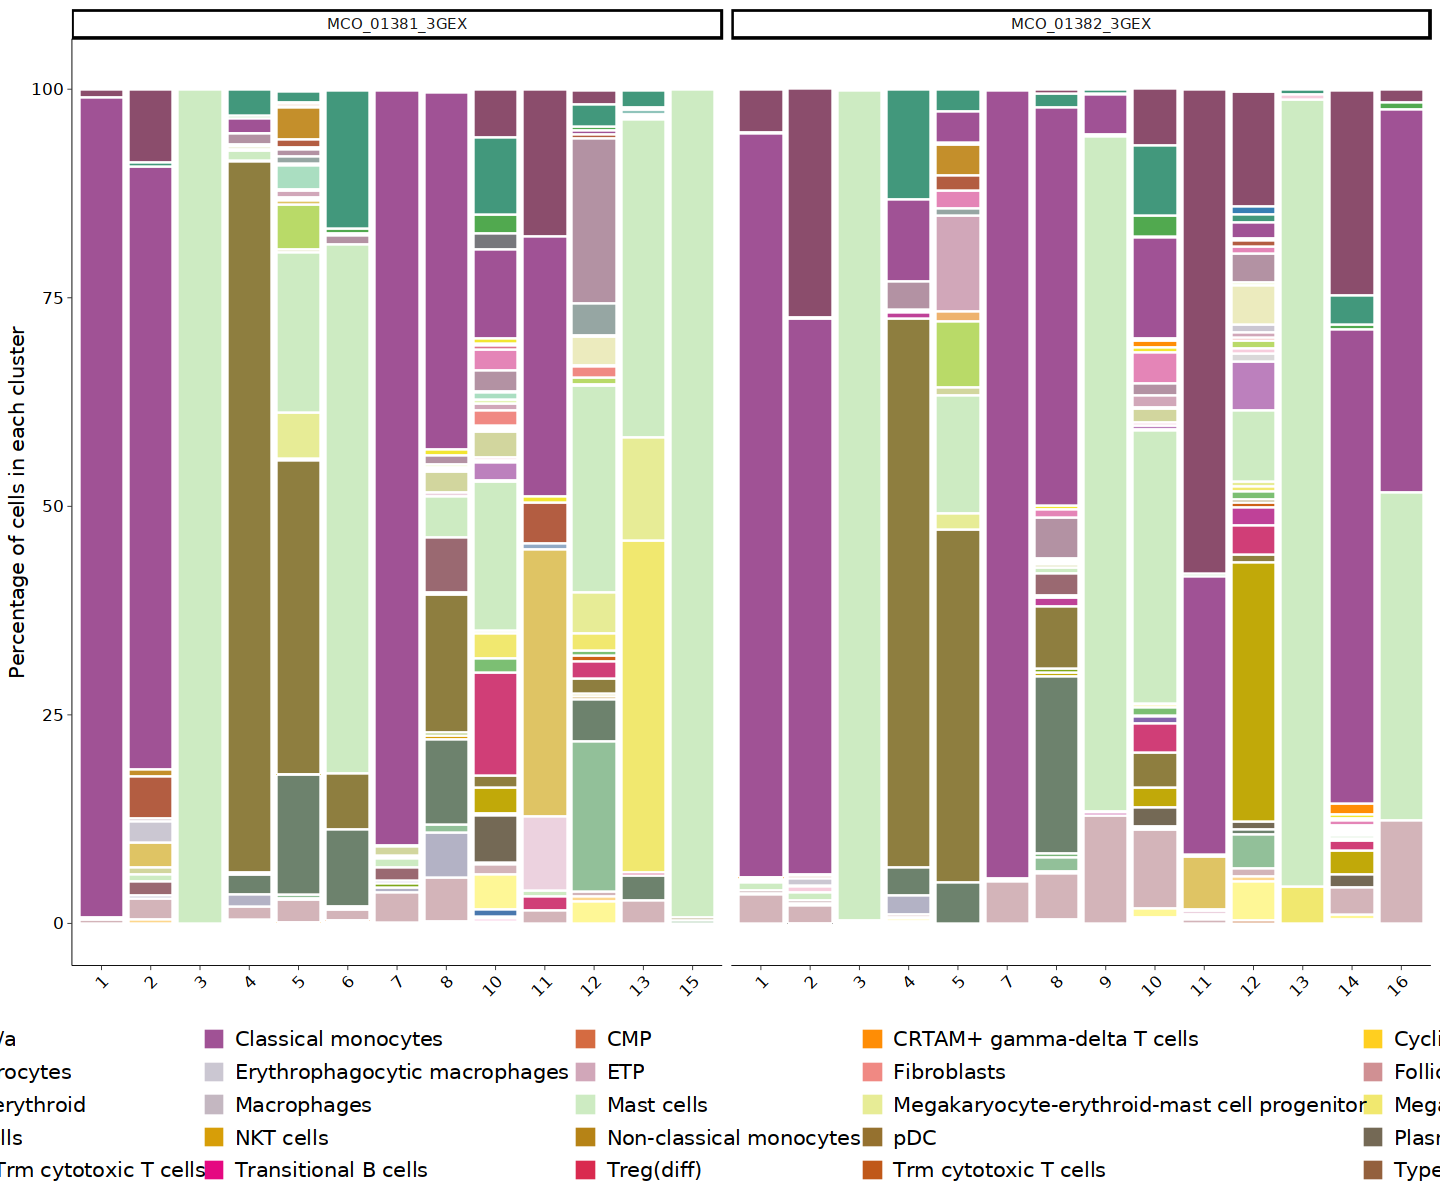

In [110]:
 #### Stacked Graph ---------------
  
  breaks.Rank<-(seq(0,100,by=25))
  labels.Rank<-as.character(breaks.Rank)
  
  cat("-------------------------------------->\t")
  cat(sprintf(as.character(labels.Rank)))
  cat("\n")
  
  
  stacked_barplot<-ggplot(data= Freq.table_filtered,
           aes(x=seurat_clusters, y=Perc, fill=CellTypist_label_Immune_ALL_low)) +
    geom_bar(stat="identity",colour='white')+
    scale_y_continuous(name=paste("Percentage of cells in each cluster",sep=" "),breaks=breaks.Rank,labels=labels.Rank,
                       limits=c(breaks.Rank[1],breaks.Rank[length(breaks.Rank)]+1))+
    scale_fill_manual(values=vector_colors_CellTypist_label_Immune_ALL_low,
                      drop=F,
                      name="Alsinet model")

stacked_barplot<-stacked_barplot+
    theme_cowplot(font_size = 2)+
    facet_grid(. ~ orig.ident, scales='free_x', space='free_x', switch="y")+   
    scale_x_discrete(name="Seurat clusters", drop=TRUE)+
    theme( strip.background = element_blank(),
           strip.placement = "outside",
           strip.text = element_text(size=12),
           panel.spacing = unit(0.2, "lines"),
           panel.background=element_rect(fill="white"),
           panel.border=element_rect(colour="white",size=0,5),
           panel.grid.major = element_blank(),
           panel.grid.minor = element_blank())+
        theme_classic()+
            theme(axis.title.y=element_text(size=12, color="black", family="sans"),
                  axis.title.x=element_blank(),
                  axis.text.y=element_text(angle=0,size=10, color="black", family="sans"),
                  axis.text.x=element_text(angle=45,size=10,vjust=1,hjust=1,color="black", family="sans"),
                  axis.line.x = element_line(size = 0.2),
                  axis.ticks.x = element_line(size = 0.2),
                  axis.ticks.y = element_line(size = 0.2),
                  axis.line.y = element_line(size = 0.2))+
            theme(legend.title = element_blank(),
                  legend.text = element_text(size=12, color="black", family="sans"),
                  legend.key.size = unit(0.5, 'cm'), #change legend key size
                  legend.key.height = unit(0.5, 'cm'), #change legend key height
                  legend.key.width = unit(0.5, 'cm'), #change legend key width
                  legend.position="bottom")+
            guides(fill=guide_legend(nrow=5,byrow=TRUE))



stacked_barplot
  




  

In [111]:
setwd(path_graphs)

svgname<-paste("Stacked_barplot_Immune_ALL_low_vs_cluster",".svg",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= stacked_barplot,
         device="svg", width =13, height = 13)
}

## Violin plot of confidence score

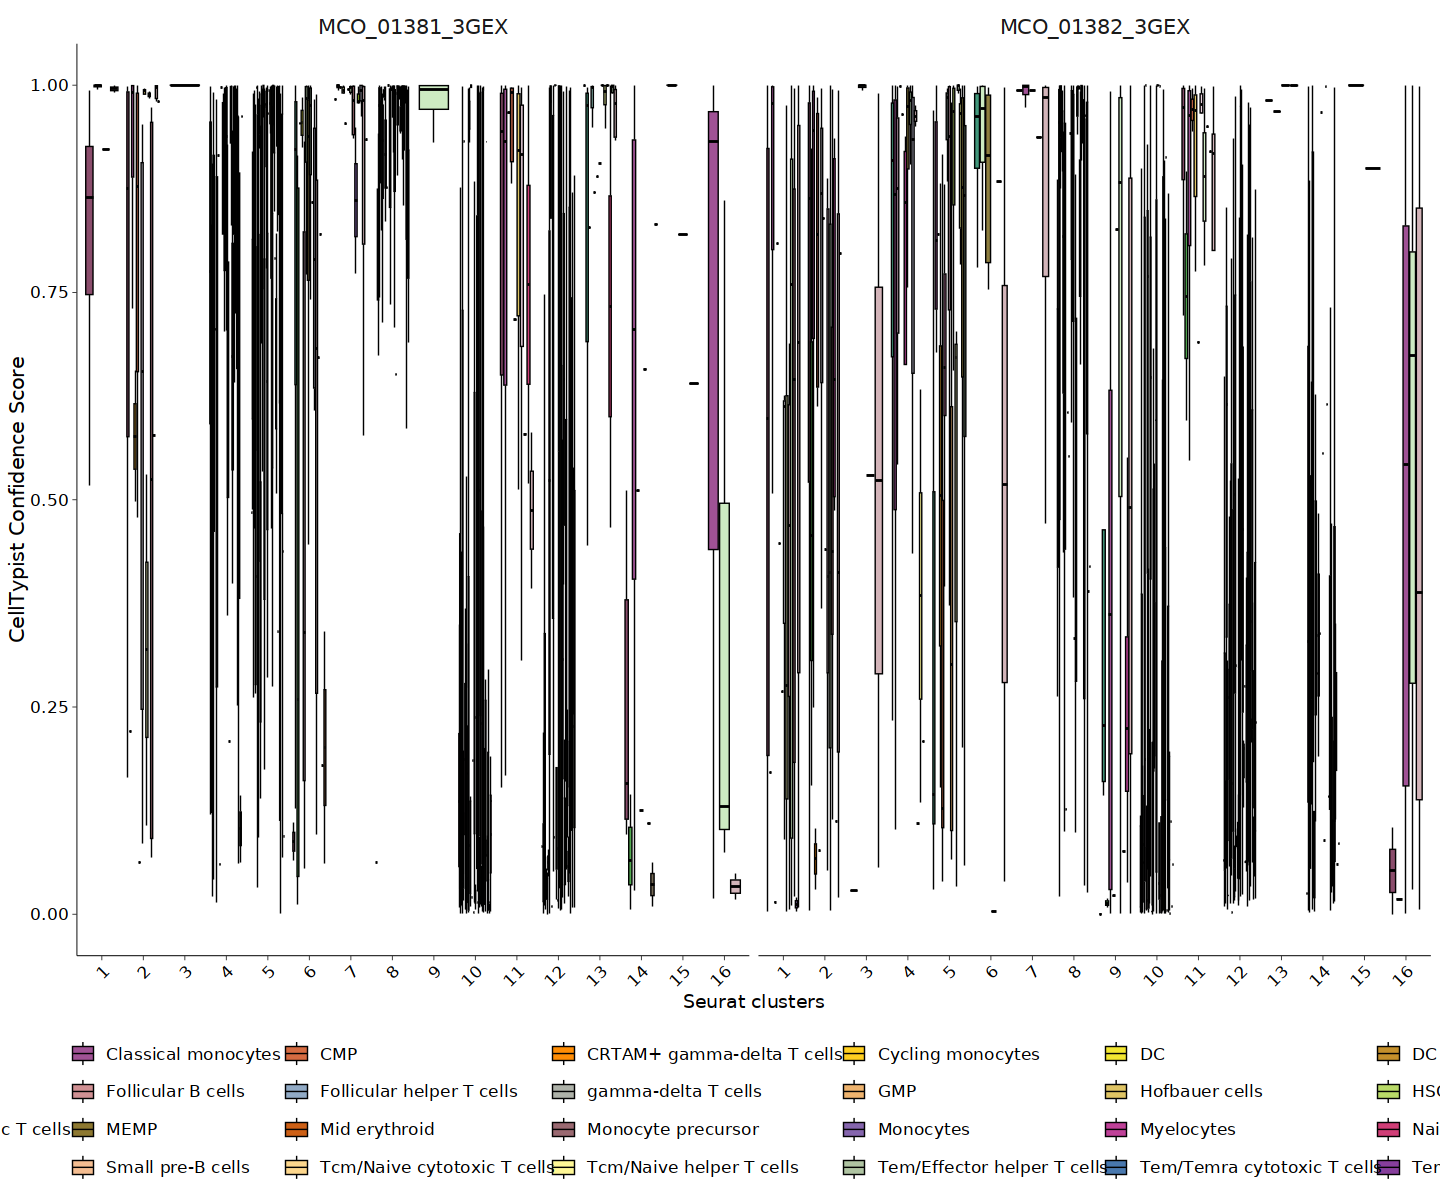

In [112]:
library(ggplot2)
library(RColorBrewer)

# 1. Define color vector
vector_colors_CellTypist_label_Immune_ALL_low <- vector_colors_CellTypist_label_Immune_ALL_low

# 2. Build the Plot (Boxplot only)
boxplot_only_plot <- ggplot(met, aes(x = seurat_clusters, 
                                     y = CellTypist_conf_score_Immune_ALL_low, 
                                     fill = CellTypist_label_Immune_ALL_low)) +
  
  # Grouped boxplots without outliers
  # width = 0.7 gives them more horizontal space since the violins are gone
  geom_boxplot(width = 0.7, 
               color = "black", 
               linewidth = 0.3,
               outlier.shape = NA, 
               position = position_dodge(width = 0.8)) +
  
  # Grid by sample
  facet_grid(. ~ orig.ident, scales = 'free_x', space = 'free_x') +
  
  # Manual colors and drop unused labels from legend
  scale_fill_manual(values = vector_colors_CellTypist_label_Immune_ALL_low,
                    drop = TRUE, 
                    name = "Alsinet label") +
  
  # Ensure X-axis drops empty clusters
  scale_x_discrete(name = "Seurat clusters", drop = TRUE) +
  
  # Standardize Y-axis for confidence scores
  scale_y_continuous(limits = c(0, 1)) +
  
  labs(y = "CellTypist Confidence Score") +
  
  # Applying your requested theme styling
  theme_classic() +
  theme(
    strip.background = element_blank(),
    strip.text = element_text(size = 12),
    axis.title.y = element_text(size = 12, color = "black"),
    axis.text.y = element_text(size = 10, color = "black"),
    axis.text.x = element_text(angle = 45, size = 10, vjust = 1, hjust = 1, color = "black"),
    axis.line = element_line(linewidth = 0.2),
    axis.ticks = element_line(linewidth = 0.2),
    legend.position = "bottom",
    legend.text = element_text(size = 10),
    legend.title = element_blank()
  ) +
  guides(fill = guide_legend(nrow = 4, byrow = TRUE))

print(boxplot_only_plot)

In [113]:
setwd(path_graphs)

svgname<-paste("Violin_plot_Immune_ALL_low_vs_cluster",".svg",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= boxplot_only_plot,
         device="svg", width =13, height = 13)
}

## Dot plot

In [114]:
summary_means <- met %>%
  group_by(orig.ident, seurat_clusters, CellTypist_label_Immune_ALL_low) %>%
  dplyr::summarise(
    mean_conf_score = mean(CellTypist_conf_score_Immune_ALL_low, na.rm = TRUE),
    cell_count = n(),
    .groups = "drop" # This replaces the need for ungroup()
  )

# View results
head(summary_means)

orig.ident,seurat_clusters,CellTypist_label_Immune_ALL_low,mean_conf_score,cell_count
<chr>,<fct>,<chr>,<dbl>,<int>
MCO_01381_3GEX,1,Alveolar macrophages,0.8096024,4
MCO_01381_3GEX,1,Classical monocytes,0.9914860,401
MCO_01381_3GEX,1,Mast cells,0.9226193,1
MCO_01381_3GEX,1,Regulatory T cells,0.9955698,2
MCO_01381_3GEX,2,Alveolar macrophages,0.7635650,21
MCO_01381_3GEX,2,CD16- NK cells,0.2206278,1


In [115]:
library(dplyr)

summary_final <- summary_means %>%
  # 1. Force the columns to characters to be safe
  mutate(
    seurat_clusters = as.character(seurat_clusters),
    orig.ident = as.character(orig.ident)
  ) %>%
  # 2. Use the explicit dplyr group_by
  dplyr::group_by(orig.ident, seurat_clusters) %>%
  # 3. Use the explicit dplyr mutate
  dplyr::mutate(
    cluster_total = sum(cell_count),
    percentage = (cell_count / cluster_total) * 100
  ) %>%
  dplyr::ungroup()

# VERIFICATION: This should now show ~1296 for Cluster 0


In [116]:
summary_final %>% filter(seurat_clusters == "0")
cat("\n")

summary_final %>% filter(seurat_clusters == "2")
cat("\n")

orig.ident,seurat_clusters,CellTypist_label_Immune_ALL_low,mean_conf_score,cell_count,cluster_total,percentage
<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>


orig.ident,seurat_clusters,CellTypist_label_Immune_ALL_low,mean_conf_score,cell_count,cluster_total,percentage
<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>
MCO_01381_3GEX,2,Alveolar macrophages,0.76356499,21,238,8.82352941
MCO_01381_3GEX,2,CD16- NK cells,0.22062777,1,238,0.42016807
MCO_01381_3GEX,2,Classical monocytes,0.89808666,172,238,72.26890756
MCO_01381_3GEX,2,DC precursor,0.57627960,2,238,0.84033613
MCO_01381_3GEX,2,DC2,0.81717683,12,238,5.04201681
MCO_01381_3GEX,2,Double-positive thymocytes,0.06260354,1,238,0.42016807
MCO_01381_3GEX,2,Erythrophagocytic macrophages,0.57484008,6,238,2.52100840
MCO_01381_3GEX,2,Hofbauer cells,0.94741706,7,238,2.94117647
MCO_01381_3GEX,2,ILC3,0.31894717,2,238,0.84033613


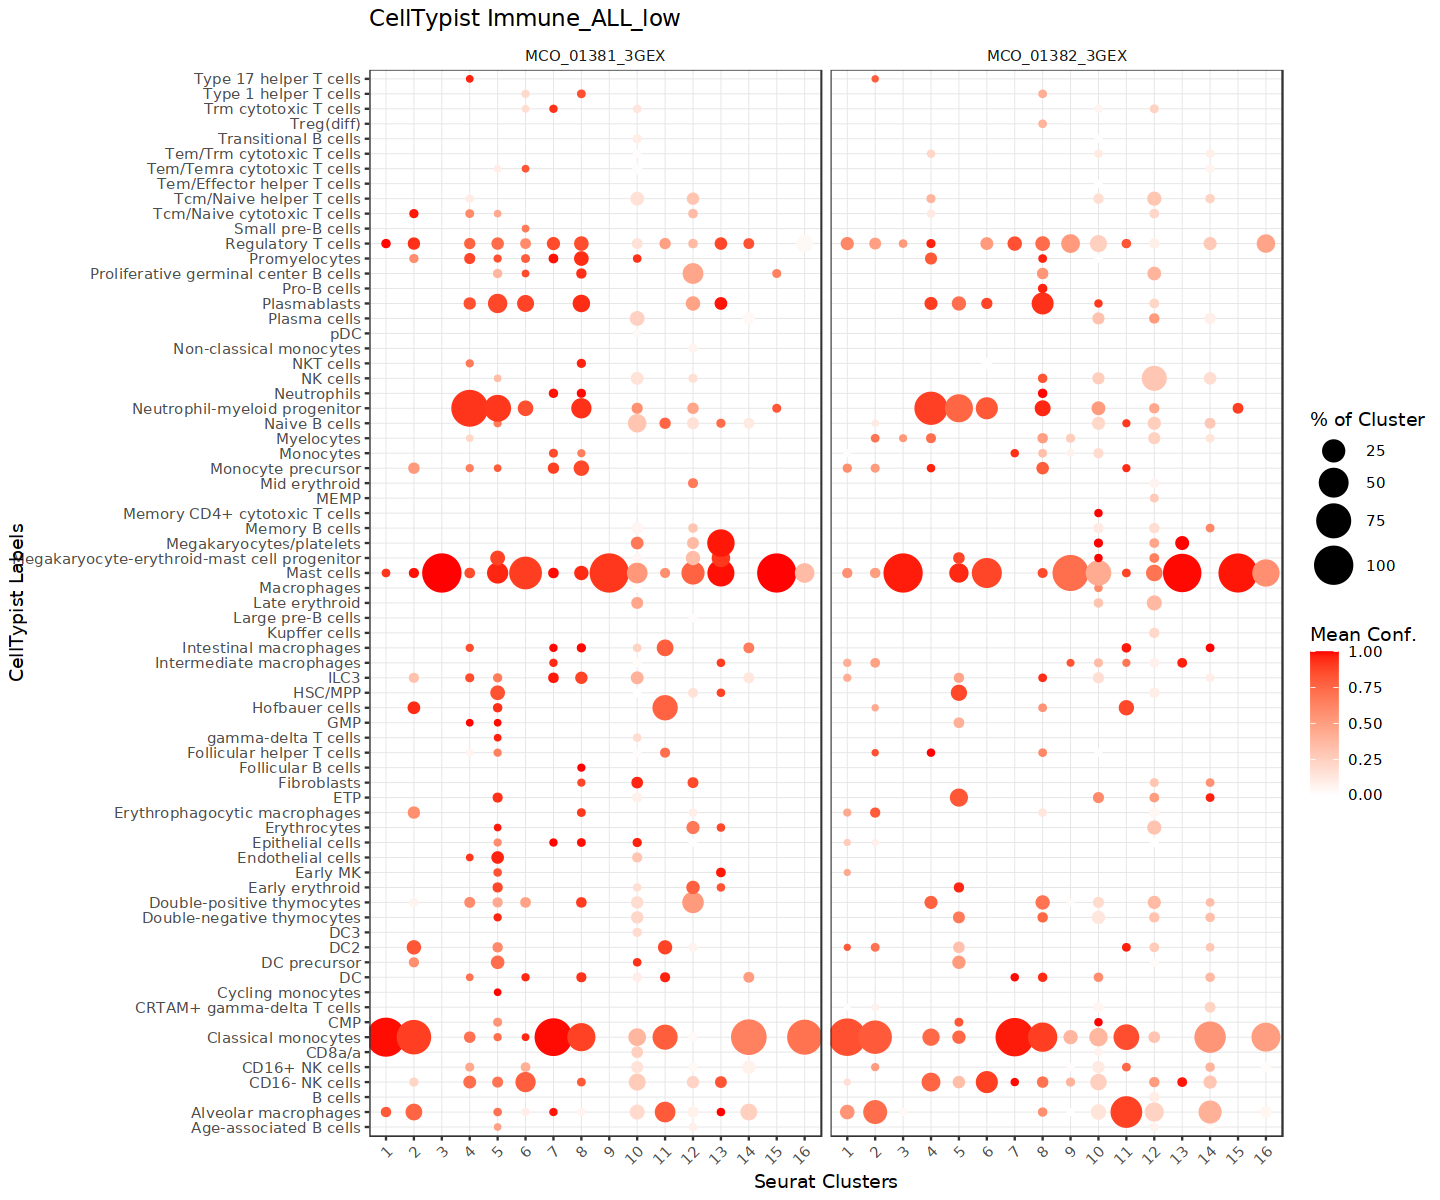

In [117]:

# 1. Sort clusters numerically for the X-axis
summary_final$seurat_clusters <- factor(summary_final$seurat_clusters, 
                                        levels = sort(as.numeric(unique(summary_final$seurat_clusters))))

# 2. Create the Dot Plot
dotplot_annotation <- ggplot(summary_final, aes(x = seurat_clusters, 
                                                y = CellTypist_label_Immune_ALL_low)) +
  # Use geom_point where size and color represent your calculated metrics
  geom_point(aes(size = percentage, color = mean_conf_score)) +
  
  # Set the color gradient from white to red
  # limits c(0,1) ensures the scale is consistent for confidence scores
  scale_color_gradient(low = "white", high = "red", limits = c(0, 1), name = "Mean Conf.") +
  
  # Adjust the size scale to make dots visible but not overlapping
  scale_size_continuous(range = c(1, 10), name = "% of Cluster") +
  
  # Grid by sample
  facet_grid(. ~ orig.ident, scales = "free_x", space = "free_x") +
  
  # Clean theme and labels
  theme_bw() +
  labs(
    title = "CellTypist Immune_ALL_low",
    x = "Seurat Clusters",
    y = "CellTypist Labels"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major = element_line(linewidth = 0.2, color = "grey90"),
    strip.background = element_blank(),
    legend.position = "right"
  )

# Display plot
dotplot_annotation

In [119]:
setwd(path_graphs)

svgname<-paste("Dot_plot_Immune_ALL_low_vs_cluster",".svg",sep='')
makesvg = TRUE

if (makesvg == TRUE)
{
  ggsave(svgname, plot= dotplot_annotation,
         device="svg", width =13, height = 13)
}

# Factor orig.ident

In [121]:
unique(adata@meta.data$orig.ident)

[1] "MCO_01381_3GEX" "MCO_01382_3GEX"

In [122]:
adata@meta.data$orig.ident<-factor(adata@meta.data$orig.ident,
                                                   levels=c('MCO_01381_3GEX','MCO_01382_3GEX'),
                                                   ordered=T)

# SAVE

In [123]:
setwd("/scratch/manuel.tardaguila/2026_Ditadi_test/processing_outputs/")

In [124]:
saveRDS(adata, file="merged_unprocessed_db_filt_clustered_QCed_reclustered_rpca_integrate_clustered_cell_annotated.rds")